In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

/Users/zhanbotaerlan/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
apple=yf.download("AAPL", start="2020-01-01", end="2025-01-01")

[*********************100%***********************]  1 of 1 completed


In [3]:
apple.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.271530,72.331686,71.029908,71.282560,135480400
2020-01-03,71.568924,72.326889,71.345145,71.501549,146322800
2020-01-06,72.139191,72.177691,70.442792,70.693043,118387200
2020-01-07,71.799919,72.403881,71.580950,72.148820,108872000
2020-01-08,72.954903,73.255683,71.503938,71.503938,132079200


<Axes: xlabel='Date'>

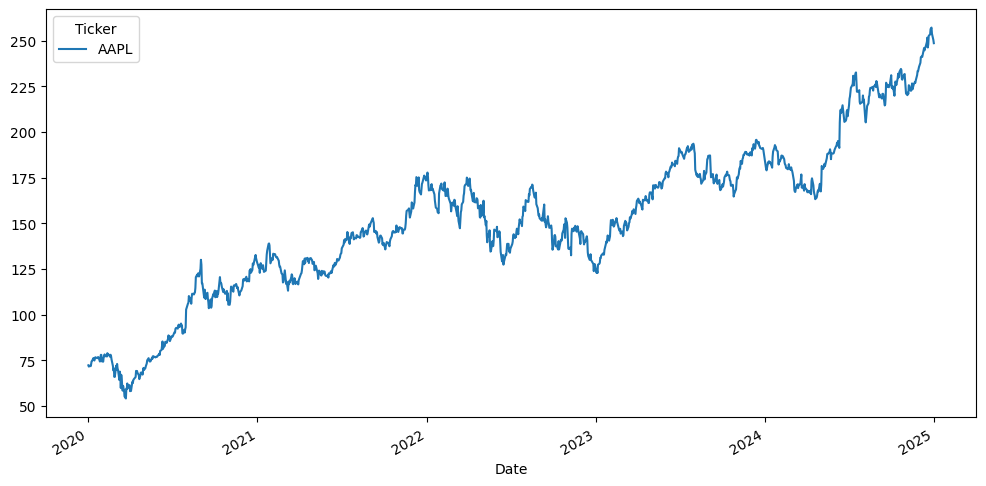

In [4]:
apple["Close"].plot(figsize=(12,6))

In [5]:
apple["Return"]=apple["Close"].pct_change() 

In [6]:
apple["Return"].describe()

count    1257.000000
mean        0.001182
std         0.019956
min        -0.128647
25%        -0.008425
50%         0.001187
75%         0.011989
max         0.119808
Name: Return, dtype: float64

In [7]:
apple["Close"]

Ticker,AAPL
Date,
2020-01-02,72.271530
2020-01-03,71.568924
2020-01-06,72.139191
2020-01-07,71.799919
2020-01-08,72.954903
...,...
2024-12-24,256.339752
2024-12-26,257.153809
2024-12-27,253.748520


In [8]:
apple["Return"] = apple[("Close", "AAPL")].pct_change()

<Axes: xlabel='Date'>

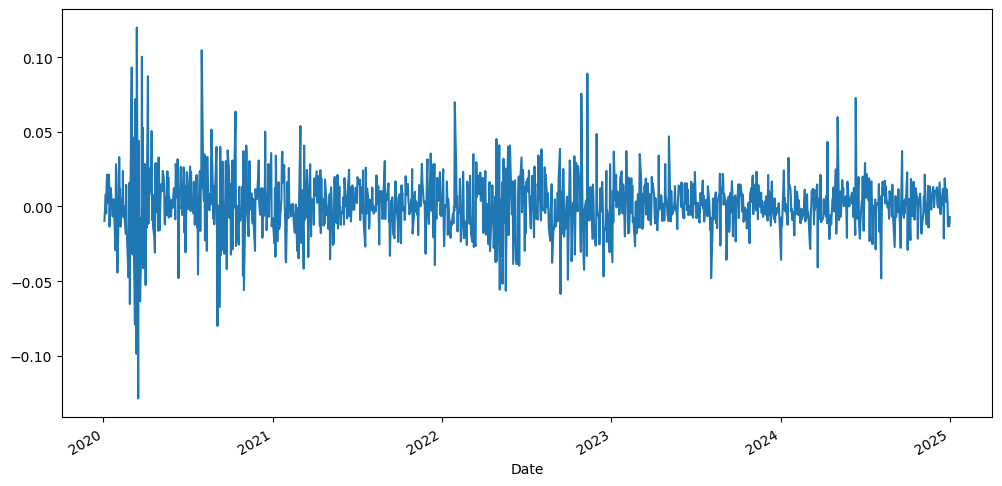

In [9]:
apple["Return"].plot(figsize=(12,6))

In [10]:
annual_volatility = apple["Return"].std()*(252 ** 0.5)
print(annual_volatility)

0.31678630795975266


In [11]:
msft = yf.download("MSFT",start="2020-01-01",end="2025-01-01")

[*********************100%***********************]  1 of 1 completed


In [12]:
msft.head()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2020-01-02,151.544250,151.648036,149.383652,149.808222,22622100
2020-01-03,149.657303,150.912154,149.128947,149.374266,21116200
2020-01-06,150.044113,150.110165,147.666500,148.204300,20813700
2020-01-07,148.676010,150.647912,148.430707,150.317697,21634100
2020-01-08,151.044220,151.714108,149.025140,149.949762,27746500


In [13]:
msft["Return"] = msft[("Close", "MSFT")].pct_change()

<Axes: xlabel='Date'>

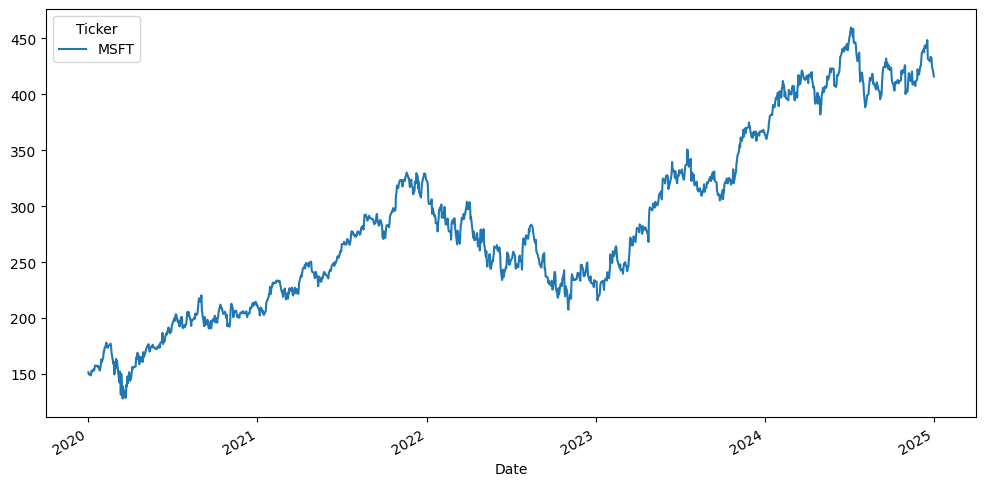

In [14]:
msft["Close"].plot(figsize=(12,6))

In [15]:
msft["Return"].describe()

count    1257.000000
mean        0.000988
std         0.019211
min        -0.147390
25%        -0.008176
50%         0.001111
75%         0.010940
max         0.142169
Name: Return, dtype: float64

<Axes: xlabel='Date'>

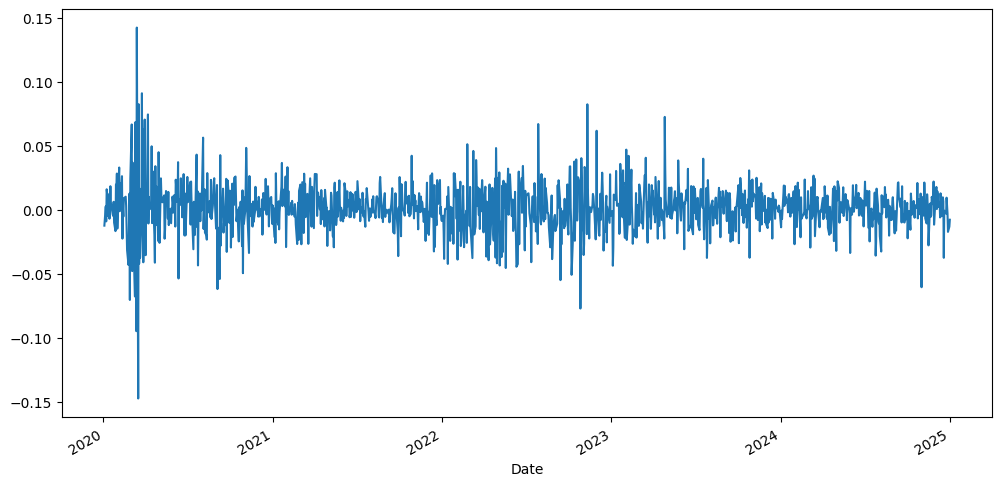

In [16]:
msft["Return"].plot(figsize=(12,6))

In [17]:
comparison=pd.DataFrame(
    {
        "Apple":[apple["Return"].mean(),apple["Return"].std()],
        "Microsoft":[msft["Return"].mean(),msft["Return"].std()]
    },
    index=["Mean Return","Volatility"]
)
comparison

,Apple,Microsoft
Mean Return,0.001182,0.000988
Volatility,0.019956,0.019211


In [18]:
returns=pd.DataFrame({
    "Apple":apple["Return"],
    "Microsoft":msft["Return"]
})

In [19]:
returns.corr()

,Apple,Microsoft
Apple,1.000000,0.748327
Microsoft,0.748327,1.000000


In [20]:
returns["Portfolio"]=0.5*returns["Apple"]+0.5*returns["Microsoft"]
returns.head()

,Apple,Microsoft,Portfolio
Date,,,
2020-01-02,NaN,NaN,NaN
2020-01-03,-0.009722,-0.012451,-0.011087
2020-01-06,0.007968,0.002585,0.005276
2020-01-07,-0.004703,-0.009118,-0.006911
2020-01-08,0.016086,0.015929,0.016007


In [21]:
returns["Portfolio"].mean()

np.float64(0.0010849657723392921)

In [22]:
returns["Portfolio"].std()

np.float64(0.01831045458059564)

In [23]:
returns["Portfolio_70_30"]=(0.7*returns["Apple"]+0.3*returns["Microsoft"])
returns["Portfolio_70_30"].std()

np.float64(0.018677353465636006)

In [24]:

returns["Portfolio_30_70"]=(0.3*returns["Apple"]+0.7*returns["Microsoft"])
returns["Portfolio_30_70"].std()

np.float64(0.018362569160282657)

In [25]:
returns[["Apple","Microsoft"]].corr()

,Apple,Microsoft
Apple,1.000000,0.748327
Microsoft,0.748327,1.000000


<Axes: xlabel='Apple', ylabel='Microsoft'>

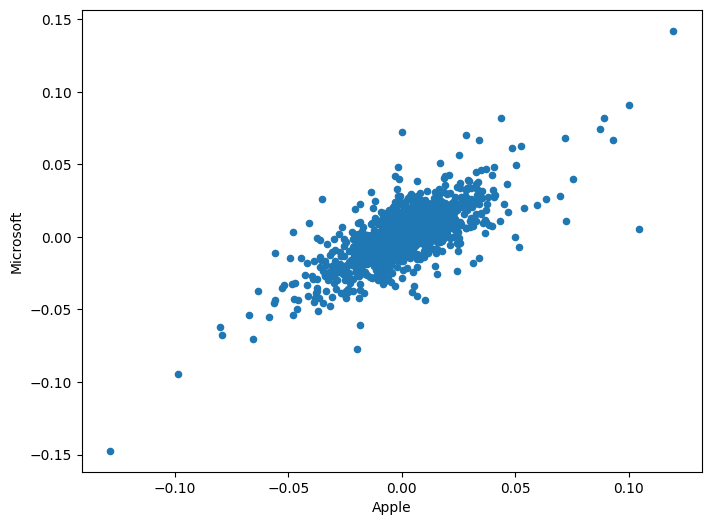

In [26]:
returns.plot.scatter(
    x="Apple",
    y="Microsoft",
figsize=(8,6)
)

In [27]:
nvda=yf.download(
    "NVDA",
    start="2020-01-01",
    end="2025-01-01"
    )

[*********************100%***********************]  1 of 1 completed


In [28]:
nvda["Return"]=nvda[("Close","NVDA")].pct_change()

In [29]:
nvda["Return"].mean()

np.float64(0.0030498670483127335)

In [30]:
nvda["Return"].std()

np.float64(0.033940480132833496)

In [31]:
comparison3=pd.DataFrame({
    "Apple":[apple["Return"].mean(),apple["Return"].std()],
    "Microsoft":[msft["Return"].mean(),msft["Return"].std()],
    "NVIDIA":[nvda["Return"].mean(),nvda["Return"].std()]
},
   index=["Mean Return","Volatility"]
                        )
comparison3

,Apple,Microsoft,NVIDIA
Mean Return,0.001182,0.000988,0.00305
Volatility,0.019956,0.019211,0.03394


In [32]:
returns3=pd.DataFrame({
    "Apple":apple["Return"],
    "Microsoft":msft["Return"],
    "NVIDIA":nvda["Return"]
})
returns3.corr()

,Apple,Microsoft,NVIDIA
Apple,1.000000,0.748327,0.606399
Microsoft,0.748327,1.000000,0.682141
NVIDIA,0.606399,0.682141,1.000000


In [33]:
returns3["Portfolio3"]=(returns3["Apple"]/3+returns3["Microsoft"]/3+returns3["NVIDIA"]/3)
returns3["Portfolio3"].mean()

np.float64(0.001739932864330439)

In [34]:
returns3["Portfolio3"].std()

np.float64(0.021612896352196286)

In [35]:
summary=pd.DataFrame({
    "Mean Return":[apple["Return"].mean(),msft["Return"].mean(),nvda["Return"].mean()],
    "Volatility":[apple["Return"].std(),msft["Return"].std(),nvda["Return"].std()],
    "Return/Risk":[
        apple["Return"].mean()/apple["Return"].std(),
        msft["Return"].mean()/msft["Return"].std(),
        nvda["Return"].mean()/nvda["Return"].std()]
},
    index=["Apple","Microsoft","NVIDIA"])
summary

,Mean Return,Volatility,Return/Risk
Apple,0.001182,0.019956,0.059237
Microsoft,0.000988,0.019211,0.051418
NVIDIA,0.003050,0.033940,0.089859


<Axes: >

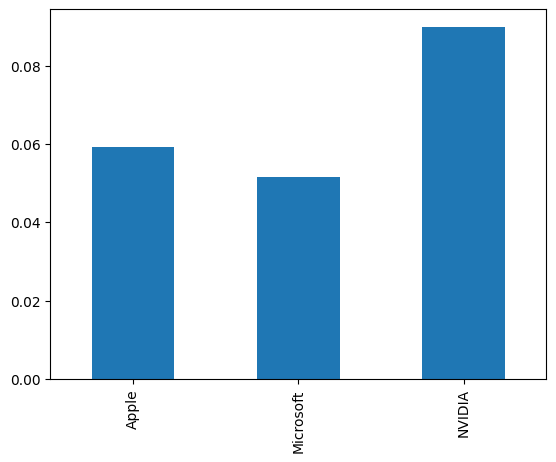

In [36]:
summary["Return/Risk"].plot.bar()

In [37]:
apple["MA50"]=apple[("Close","AAPL")].rolling(50).mean()
apple[["MA50"]].tail()

Price,MA50
Ticker,
Date,
2024-12-24,234.123972
2024-12-26,234.628848
2024-12-27,235.106674
2024-12-30,235.509851
2024-12-31,235.821157


<Axes: xlabel='Date'>

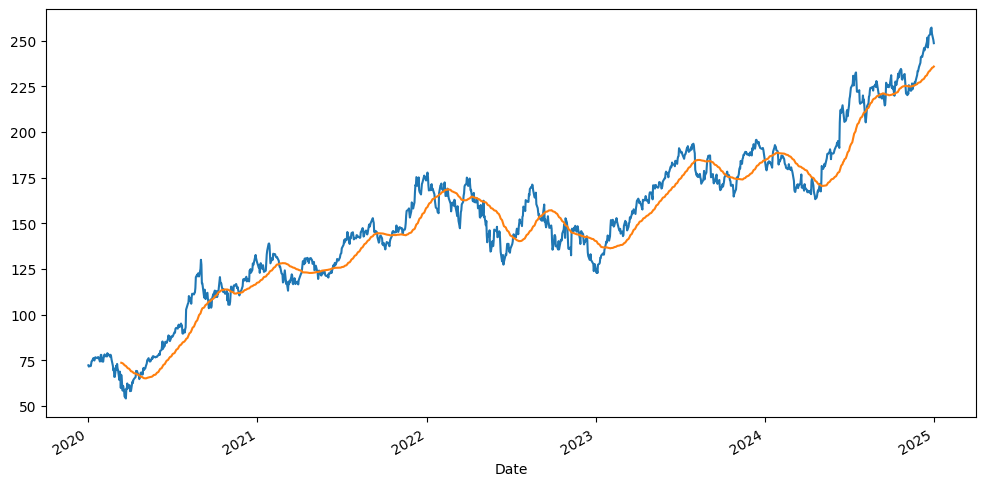

In [38]:
apple[("Close","AAPL")].plot(figsize=(12,6))
apple["MA50"].plot()

In [39]:
apple["Signal"]=(apple[("Close","AAPL")]>apple["MA50"]).astype(int)
apple[["Signal"]].tail()

Price,Signal
Ticker,
Date,
2024-12-24,1
2024-12-26,1
2024-12-27,1
2024-12-30,1
2024-12-31,1


In [40]:
apple["Strategy_Return"]=(apple["Signal"].shift(1)*apple["Return"])

In [41]:
apple["Strategy_Return"].mean()

np.float64(0.0007372548428893669)

In [42]:
apple["Signal"].value_counts()

Signal
1    766
0    492
Name: count, dtype: int64

In [43]:
apple["Strategy_Return"].describe()

count    1257.000000
mean        0.000737
std         0.013076
min        -0.080061
25%        -0.001711
50%         0.000000
75%         0.003734
max         0.104689
Name: Strategy_Return, dtype: float64

<Axes: xlabel='Date'>

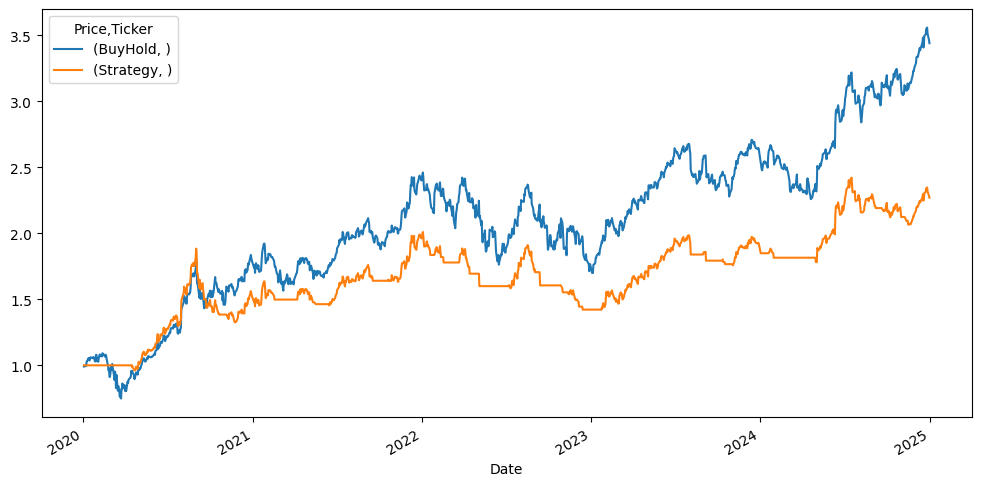

In [44]:
apple["BuyHold"]=(1+apple["Return"]).cumprod()
apple["Strategy"]=(1+apple["Strategy_Return"]).cumprod()
apple[["BuyHold","Strategy"]].plot(figsize=(12,6))

In [45]:
apple["Strategy_Return"].std()

np.float64(0.013075721093606777)

In [46]:
apple["Strategy_Return"].mean()/apple["Strategy_Return"].std()

np.float64(0.05638349408124338)

In [47]:
apple["Return"].mean()/apple["Return"].std()

np.float64(0.05923685228327044)

In [48]:
apple["MA20"]=apple[("Close","AAPL")].rolling(20).mean()
apple["Signal20"]=(apple[("Close","AAPL")]>apple["MA20"]).astype(int)
apple["Strategy20_Return"]=(apple["Signal20"].shift(1)*apple["Return"])

In [49]:
apple["Strategy20_Return"].mean()

np.float64(0.0010714994184837904)

In [50]:
apple["Strategy20_Return"].std()

np.float64(0.013093737778391443)

In [51]:
apple["MA50"]=apple[("Close","AAPL")].rolling(50).mean()
apple["Signal50"]=(apple[("Close","AAPL")]>apple["MA50"]).astype(int)
apple["Strategy50_Return"]=(apple["Signal50"].shift(1)*apple["Return"])

In [52]:
apple["Strategy50_Return"].mean()

np.float64(0.0007372548428893669)

In [53]:
apple["Strategy50_Return"].std()

np.float64(0.013075721093606777)

In [54]:
apple["MA200"]=apple[("Close","AAPL")].rolling(200).mean()
apple["Signal200"]=(apple[("Close","AAPL")]>apple["MA200"]).astype(int)
apple["Strategy200_Return"]=(apple["Signal200"].shift(1)*apple["Return"])

In [55]:
apple["Strategy200_Return"].mean()

np.float64(0.0004910107731412337)

In [56]:
apple["Strategy200_Return"].std()

np.float64(0.012534193584961701)

In [57]:
close=msft["Close"]
if isinstance(close,pd.DataFrame):
    close=close.iloc[:,0]
returns=msft["Return"]
if isinstance(returns,pd.DataFrame):
    returns=returns.iloc[:,0]
    
msft["MA20"]=close.rolling(20).mean()
msft["Signal20"]=(
      close>msft["MA20"]
).astype(int)
msft["Strategy20_Return"]=(
    msft["Signal20"].shift(1)*returns
)

In [58]:
msft["Strategy20_Return"].mean()

np.float64(0.00020102984639032458)

In [59]:
msft["Strategy20_Return"].std()

np.float64(0.012198477688204172)

In [60]:
close=msft["Close"]
if isinstance(close,pd.DataFrame):
    close=close.iloc[:,0]
returns=msft["Return"]
if isinstance(returns,pd.DataFrame):
    returns=returns.iloc[:,0]
    
msft["MA50"]=close.rolling(50).mean()
msft["Signal50"]=(
      close>msft["MA50"]
).astype(int)
msft["Strategy50_Return"]=(
    msft["Signal50"].shift(1)*returns
)

In [61]:
msft["Strategy50_Return"].mean()

np.float64(0.00034572819392936726)

In [62]:
msft["Strategy50_Return"].std()

np.float64(0.01235099997882161)

In [63]:
close=msft["Close"]
if isinstance(close,pd.DataFrame):
    close=close.iloc[:,0]
returns=msft["Return"]
if isinstance(returns,pd.DataFrame):
    returns=returns.iloc[:,0]
    
msft["MA100"]=close.rolling(100).mean()
msft["Signal100"]=(
      close>msft["MA100"]
).astype(int)
msft["Strategy100_Return"]=(
    msft["Signal100"].shift(1)*returns
)

In [64]:
msft["Strategy100_Return"].mean()

np.float64(0.00047313651474182255)

In [65]:
msft["Strategy100_Return"].std()

np.float64(0.012275596988589436)

In [66]:
close=msft["Close"]
if isinstance(close,pd.DataFrame):
    close=close.iloc[:,0]
returns=msft["Return"]
if isinstance(returns,pd.DataFrame):
    returns=returns.iloc[:,0]
    
msft["MA200"]=close.rolling(200).mean()
msft["Signal200"]=(
      close>msft["MA200"]
).astype(int)
msft["Strategy200_Return"]=(
    msft["Signal200"].shift(1)*returns
)

In [67]:
msft["Strategy200_Return"].mean()

np.float64(0.00043430809609235863)

In [68]:
msft["Strategy200_Return"].std()

np.float64(0.01134753762494159)

In [69]:
nvda["MA20"]=nvda[("Close","NVDA")].rolling(20).mean()
nvda["Signal20"]=(nvda[("Close","NVDA")]>nvda["MA20"]).astype(int)
nvda["Strategy20_Return"]=(nvda["Signal20"].shift(1)*nvda["Return"])

In [70]:
nvda["Strategy20_Return"].mean()

np.float64(0.0022164814799617875)

In [71]:
nvda["Strategy20_Return"].std()

np.float64(0.024446064519360034)

In [72]:
nvda["MA50"]=nvda[("Close","NVDA")].rolling(50).mean()
nvda["Signal50"]=(nvda[("Close","NVDA")]>nvda["MA50"]).astype(int)
nvda["Strategy50_Return"]=(nvda["Signal50"].shift(1)*nvda["Return"])

In [73]:
nvda["Strategy50_Return"].mean()

np.float64(0.0021217128020052643)

In [74]:
nvda["Strategy50_Return"].std()

np.float64(0.025423547106345847)

In [75]:
nvda["MA100"]=nvda[("Close","NVDA")].rolling(100).mean()
nvda["Signal100"]=(nvda[("Close","NVDA")]>nvda["MA100"]).astype(int)
nvda["Strategy100_Return"]=(nvda["Signal100"].shift(1)*nvda["Return"])

In [76]:
nvda["Strategy100_Return"].mean()

np.float64(0.0021408713273738046)

In [77]:
nvda["Strategy100_Return"].std()

np.float64(0.02522956349841058)

In [78]:
nvda["MA200"]=nvda[("Close","NVDA")].rolling(200).mean()
nvda["Signal200"]=(nvda[("Close","NVDA")]>nvda["MA200"]).astype(int)
nvda["Strategy200_Return"]=(nvda["Signal200"].shift(1)*nvda["Return"])

In [79]:
nvda["Strategy200_Return"].mean()

np.float64(0.002190359927159533)

In [80]:
nvda["Strategy200_Return"].std()

np.float64(0.025558065082287824)

In [81]:
import yfinance as yf
kaspi=yf.download("KSPI",start="2024-01-19",end="2025-01-01")
kaspi.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,KSPI,KSPI,KSPI,KSPI,KSPI
Date,,,,,
2024-01-19,84.427689,84.427689,79.826698,81.375024,3410500
2024-01-22,80.178589,81.954761,78.858994,80.275360,1019600
2024-01-23,80.055435,80.917574,80.027286,80.178597,340300
2024-01-24,80.160995,81.155088,79.166896,80.979145,381000
2024-01-25,79.800308,80.407324,79.166902,80.055431,120600


In [82]:
print("First date:",kaspi.index.min())
print("Last date:",kaspi.index.max())
print("Number of observations:",len(kaspi))

First date: 2024-01-19 00:00:00
Last date: 2024-12-31 00:00:00
Number of observations: 240


In [83]:
print(type(apple["Close"]))
print(type(kaspi["Close"]))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [84]:
kaspi.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 240 entries, 2024-01-19 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, KSPI)   240 non-null    float64
 1   (High, KSPI)    240 non-null    float64
 2   (Low, KSPI)     240 non-null    float64
 3   (Open, KSPI)    240 non-null    float64
 4   (Volume, KSPI)  240 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.2 KB


In [85]:
kaspi.describe()

Price,Close,High,Low,Open,Volume
Ticker,KSPI,KSPI,KSPI,KSPI,KSPI
count,240.000000,240.000000,240.000000,240.000000,2.400000e+02
mean,104.036823,106.051336,102.221185,104.205430,3.147038e+05
std,11.660210,11.977623,11.452539,11.739213,4.394433e+05
min,76.554100,77.275471,74.794640,76.254987,6.780000e+04
25%,97.314619,99.546683,95.300848,97.736662,1.549000e+05
50%,103.823441,106.199247,101.803013,103.733236,2.108000e+05
75%,114.521023,116.357194,112.787342,114.415065,3.263000e+05
max,126.117218,130.662965,124.553480,126.008122,5.114700e+06


<Axes: xlabel='Date'>

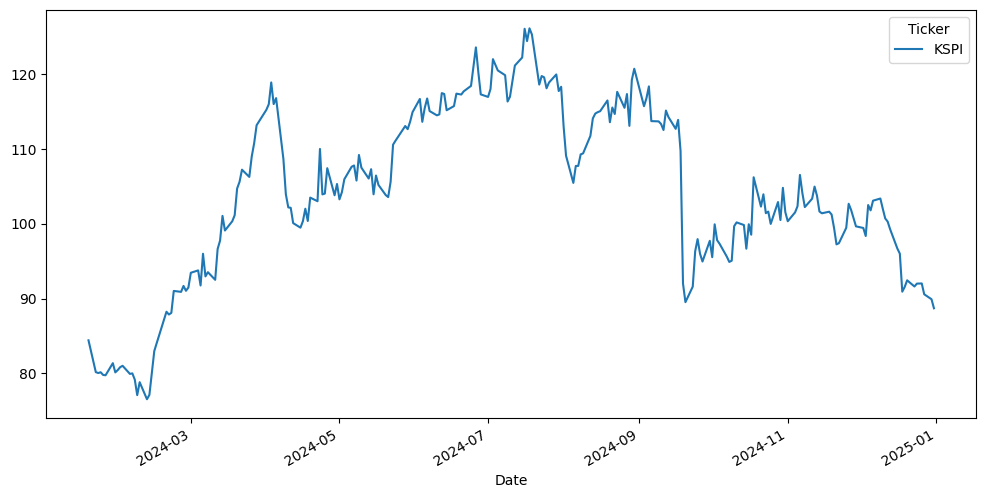

In [86]:
kaspi["Close"].plot(figsize=(12,6))

In [87]:
kaspi["Return"]=kaspi[("Close","KSPI")].pct_change()

<Axes: xlabel='Date'>

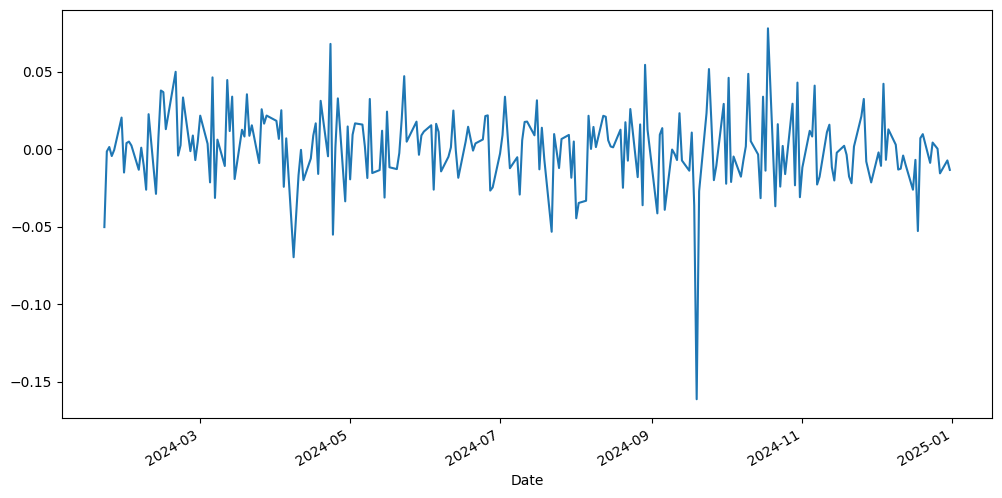

In [88]:
kaspi["Return"].plot(figsize=(12,6))

In [89]:
kaspi["Return"].mean()

np.float64(0.0005258797825637222)

In [90]:
kaspi["Return"].std()

np.float64(0.02506912907100392)

In [91]:
kaspi["Return"].describe()

count    239.000000
mean       0.000526
std        0.025069
min       -0.161331
25%       -0.013499
50%        0.001319
75%        0.015338
max        0.077844
Name: Return, dtype: float64

<Axes: >

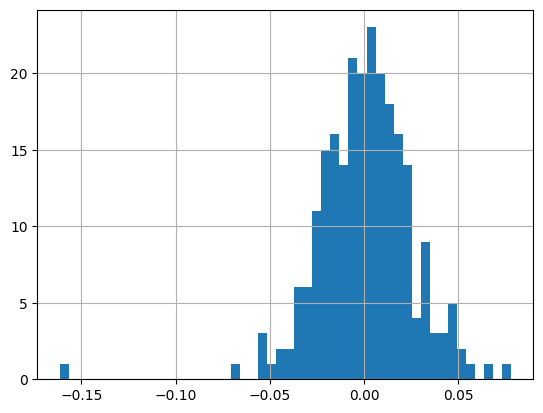

In [92]:
kaspi["Return"].hist(bins=50)

In [93]:
halyk=yf.download("HSBK.IL",start="2020-01-01",end="2025-01-01")
halyk.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,HSBK.IL,HSBK.IL,HSBK.IL,HSBK.IL,HSBK.IL
Date,,,,,
2020-01-02,4.804459,4.840313,4.750678,4.822386,20916
2020-01-03,4.822385,4.840312,4.822385,4.840312,27022
2020-01-06,4.822385,4.840312,4.804458,4.822385,5518
2020-01-07,4.858239,4.894093,4.804458,4.822385,25830
2020-01-08,4.965802,4.983729,4.876166,4.965802,73461


In [94]:

halyk.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1262 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, HSBK.IL)   1262 non-null   float64
 1   (High, HSBK.IL)    1262 non-null   float64
 2   (Low, HSBK.IL)     1262 non-null   float64
 3   (Open, HSBK.IL)    1262 non-null   float64
 4   (Volume, HSBK.IL)  1262 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.2 KB


In [95]:
halyk.describe()

Price,Close,High,Low,Open,Volume
Ticker,HSBK.IL,HSBK.IL,HSBK.IL,HSBK.IL,HSBK.IL
count,1262.000000,1262.000000,1262.000000,1262.000000,1.262000e+03
mean,7.170499,7.298254,7.051372,7.188112,9.120582e+04
std,2.812835,2.846004,2.783723,2.820511,1.016693e+05
min,2.524134,2.803796,2.509792,2.524134,0.000000e+00
25%,4.804459,4.900387,4.689769,4.820821,2.902125e+04
50%,6.270176,6.356212,6.171474,6.280565,5.641400e+04
75%,8.688562,8.889686,8.592310,8.722598,1.139480e+05
max,14.248777,15.089089,14.204935,14.248776,1.035557e+06


In [96]:
halyk["Return"]=halyk[("Close","HSBK.IL")].pct_change()

In [97]:
halyk["Return"].mean()

np.float64(0.001232399893804575)

In [98]:
halyk["Return"].std()

np.float64(0.02721862689657805)

In [99]:
halyk["Return"].describe()

count    1261.000000
mean        0.001232
std         0.027219
min        -0.193357
25%        -0.009208
50%         0.000000
75%         0.011111
max         0.268164
Name: Return, dtype: float64

<Axes: xlabel='Date'>

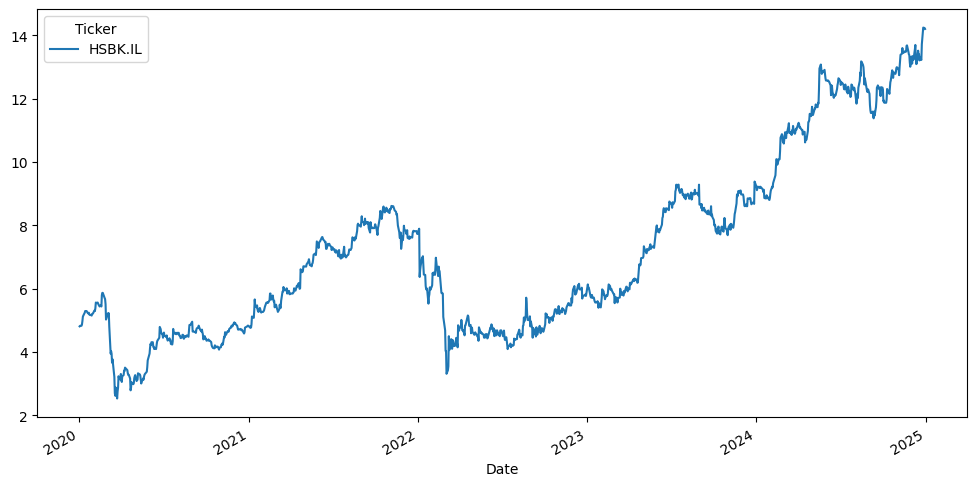

In [100]:
halyk["Close"].plot(figsize=(12,6))

<Axes: xlabel='Date'>

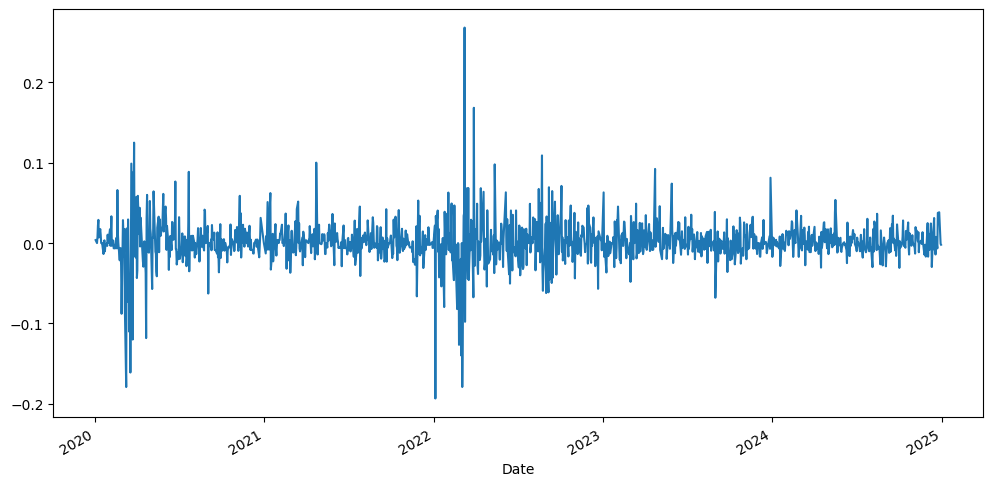

In [101]:
halyk["Return"].plot(figsize=(12,6))

In [102]:
kap=yf.download("KAP.IL",start="2020-01-01",end="2025-01-01")
kap.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,KAP.IL,KAP.IL,KAP.IL,KAP.IL,KAP.IL
Date,,,,,
2020-01-02,8.602340,8.668512,8.536168,8.602340,16967
2020-01-03,8.933200,8.933200,8.668513,8.701598,28908
2020-01-06,8.933200,8.933200,8.734684,8.933200,21819
2020-01-07,8.867026,8.966284,8.800855,8.933198,18560
2020-01-08,8.767770,9.032457,8.668512,9.032457,18808


In [103]:
kap.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1262 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, KAP.IL)   1262 non-null   float64
 1   (High, KAP.IL)    1262 non-null   float64
 2   (Low, KAP.IL)     1262 non-null   float64
 3   (Open, KAP.IL)    1262 non-null   float64
 4   (Volume, KAP.IL)  1262 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.2 KB


In [104]:
kap.describe()

Price,Close,High,Low,Open,Volume
Ticker,KAP.IL,KAP.IL,KAP.IL,KAP.IL,KAP.IL
count,1262.000000,1262.000000,1262.000000,1262.000000,1.262000e+03
mean,23.256802,23.747431,22.784583,23.304080,1.233662e+05
std,9.125577,9.270175,8.961159,9.112997,1.376871e+05
min,7.543591,7.874449,6.749529,6.749529,0.000000e+00
25%,17.478196,18.437149,16.964132,17.656578,4.769450e+04
50%,22.618841,23.208199,22.143456,22.693429,8.399000e+04
75%,33.000601,33.573425,32.506954,33.062386,1.509210e+05
max,40.580448,40.665874,39.042660,40.153281,1.554310e+06


<Axes: xlabel='Date'>

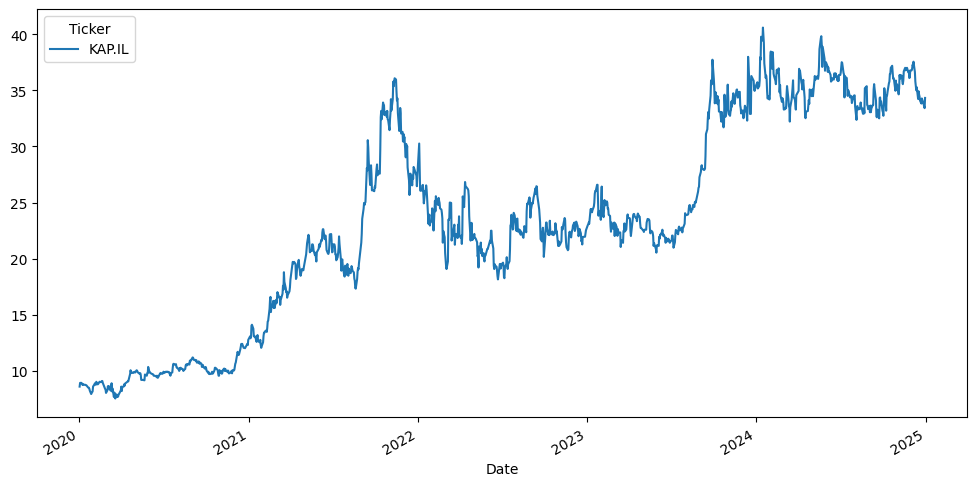

In [105]:
kap["Close"].plot(figsize=(12,6))

In [106]:
kap["Return"]=kap[("Close","KAP.IL")].pct_change()

In [107]:
kap["Return"].mean()

np.float64(0.001507620442120786)

In [108]:
kap["Return"].std()

np.float64(0.02877509713718329)

In [109]:
kap["Return"].describe()

count    1261.000000
mean        0.001508
std         0.028775
min        -0.134328
25%        -0.013819
50%         0.000000
75%         0.015171
max         0.188679
Name: Return, dtype: float64

<Axes: xlabel='Date'>

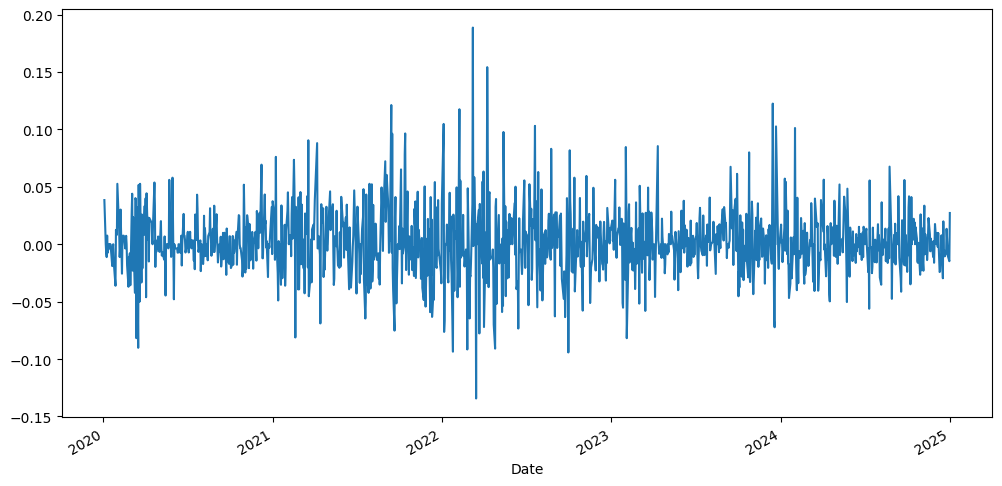

In [110]:
kap["Return"].plot(figsize=(12,6))

In [111]:
kaspi["Return"].mean()/kaspi["Return"].std()

np.float64(0.020977185967420715)

In [112]:
halyk["Return"].mean()/halyk["Return"].std()

np.float64(0.045277812818673574)

In [113]:
kap["Return"].mean()/kap["Return"].std()

np.float64(0.05239323554437748)

In [114]:
returns_kz=pd.DataFrame({
    "Kaspi":kaspi["Return"],
    "Halyk":halyk["Return"],
    "KAP":kap["Return"]})
returns_kz.corr()

,Kaspi,Halyk,KAP
Kaspi,1.000000,0.100485,0.086057
Halyk,0.100485,1.000000,0.183672
KAP,0.086057,0.183672,1.000000


In [115]:
returns_kz.mean()

Kaspi    0.000526
Halyk    0.001232
KAP      0.001508
dtype: float64

In [116]:
portfolio_kz=(returns_kz["Kaspi"]+returns_kz["Halyk"]+returns_kz["KAP"])/3

In [117]:
portfolio_kz.mean()

np.float64(0.0007918436232103257)

In [118]:
portfolio_kz.std()

np.float64(0.013221592652606475)

In [119]:
portfolio_kz.mean()/portfolio_kz.std()

np.float64(0.05989018448955341)

In [120]:
import pandas as pd
us_corr=pd.DataFrame(
    [[1,0.748,0.606],
     [0.748,1,0.682],
     [0.606,0.682,1]],
    index=["Apple","Microsoft","NVIDIA"],
    columns=["Apple","Microsoft","NVIDIA"])
us_corr

,Apple,Microsoft,NVIDIA
Apple,1.000,0.748,0.606
Microsoft,0.748,1.000,0.682
NVIDIA,0.606,0.682,1.000


In [121]:
kz_corr=pd.DataFrame(
    [[1,0.100,0.086],
     [0.100,1,0.184],
     [0.086,0.184,1]],
    index=["Kaspi","Halyk","KAP"],
    columns=["Kaspi","Halyk","KAP"])
kz_corr

,Kaspi,Halyk,KAP
Kaspi,1.000,0.100,0.086
Halyk,0.100,1.000,0.184
KAP,0.086,0.184,1.000


In [122]:
kaspi["MA20"]=kaspi[("Close","KSPI")].rolling(20).mean()

In [123]:
kaspi["Signal20"]=0
kaspi.loc[kaspi[("Close","KSPI")]>kaspi["MA20"],"Signal20"]=1

In [124]:
kaspi["Strategy20"]=kaspi["Signal20"].shift(1)*kaspi["Return"]

In [125]:
kaspi["Strategy20"].mean()

np.float64(0.0003703529844685472)

In [126]:
kaspi["Strategy20"].std()

np.float64(0.017409231447386393)

In [127]:
kaspi["Strategy20"].mean()/kaspi["Strategy20"].std()

np.float64(0.021273367844400017)

<Axes: xlabel='Date'>

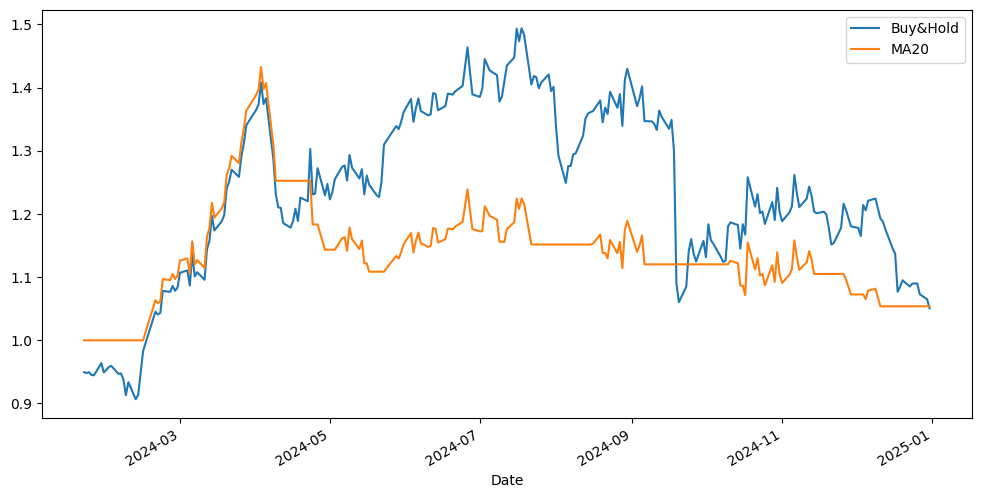

In [128]:
comparison=pd.DataFrame({
    "Buy&Hold":(1+kaspi["Return"]).cumprod(),
    "MA20":(1+kaspi["Strategy20"]).cumprod()
})
comparison.plot(figsize=(12,6))

In [129]:
kaspi["MA50"]=kaspi[("Close","KSPI")].rolling(50).mean()

In [130]:
kaspi["Signal50"]=0
kaspi.loc[kaspi[("Close","KSPI")]>kaspi["MA50"],"Signal50"]=1

In [131]:
kaspi["Strategy50"]=kaspi["Signal50"].shift(1)*kaspi["Return"]

In [132]:
kaspi["Strategy50"].mean()

np.float64(-0.0012669739225253931)

In [133]:
kaspi["Strategy50"].std()

np.float64(0.014119980801625086)

In [134]:
kaspi["Strategy50"].mean()/kaspi["Strategy50"].std()

np.float64(-0.08972915334131158)

In [135]:
kaspi["MA100"]=kaspi[("Close","KSPI")].rolling(100).mean()

In [136]:
kaspi["Signal100"]=0
kaspi.loc[kaspi[("Close","KSPI")]>kaspi["MA100"],"Signal100"]=1

In [137]:
kaspi["Strategy100"]=kaspi["Signal100"].shift(1)*kaspi["Return"]

In [138]:
kaspi["Strategy100"].mean()

np.float64(-0.00027042659733024363)

In [139]:
kaspi["Strategy100"].std()

np.float64(0.010304083869528895)

In [140]:
kaspi["Strategy100"].mean()/kaspi["Strategy100"].std()

np.float64(-0.026244603669225333)

In [141]:

kaspi["MA200"]=kaspi[("Close","KSPI")].rolling(200).mean()

In [142]:
kaspi["Signal200"]=0
kaspi.loc[kaspi[("Close","KSPI")]>kaspi["MA200"],"Signal200"]=1

In [143]:
kaspi["Strategy200"]=kaspi["Signal200"].shift(1)*kaspi["Return"]

In [144]:
kaspi["Strategy200"].mean()

np.float64(-9.560353640346478e-05)

In [145]:
kaspi["Strategy200"].std()

np.float64(0.0014779948055763993)

In [146]:
kaspi["Strategy200"].mean()/kaspi["Strategy200"].std()

np.float64(-0.0646846227353151)

In [147]:
kaspi["Strategy200"].describe()

count    239.000000
mean      -0.000096
std        0.001478
min       -0.022849
25%        0.000000
50%        0.000000
75%        0.000000
max        0.000000
Name: Strategy200, dtype: float64

In [148]:
kaspi["Strategy200"].tail()

Date
2024-12-24    0.0
2024-12-26    0.0
2024-12-27   -0.0
2024-12-30   -0.0
2024-12-31   -0.0
Name: Strategy200, dtype: float64

In [149]:
kaspi["Signal200"].value_counts()

Signal200
0    239
1      1
Name: count, dtype: int64

In [150]:
halyk["MA20"]=halyk[("Close","HSBK.IL")].rolling(20).mean()

In [151]:
halyk["Signal20"]=0
halyk.loc[halyk[("Close","HSBK.IL")]>halyk["MA20"],"Signal20"]=1

In [152]:
halyk["Strategy20"]=halyk["Signal20"].shift(1)*halyk["Return"]

In [153]:
halyk["Strategy20"].mean()

np.float64(0.000780611029974455)

In [154]:
halyk["Strategy20"].std()

np.float64(0.01744628028483234)

In [155]:
halyk["Strategy20"].mean()/halyk["Strategy20"].std()

np.float64(0.04474369419899279)

In [156]:
halyk["MA50"]=halyk[("Close","HSBK.IL")].rolling(50).mean()

In [157]:
halyk["Signal50"]=0
halyk.loc[halyk[("Close","HSBK.IL")]>halyk["MA50"],"Signal50"]=1

In [158]:
halyk["Strategy50"]=halyk["Signal50"].shift(1)*halyk["Return"]

In [159]:
halyk["Strategy50"].mean()

np.float64(0.0008946524785232708)

In [160]:
halyk["Strategy50"].std()

np.float64(0.015892488800180276)

In [161]:
halyk["Strategy50"].mean()/halyk["Strategy50"].std()

np.float64(0.0562940449272566)

<Axes: xlabel='Date'>

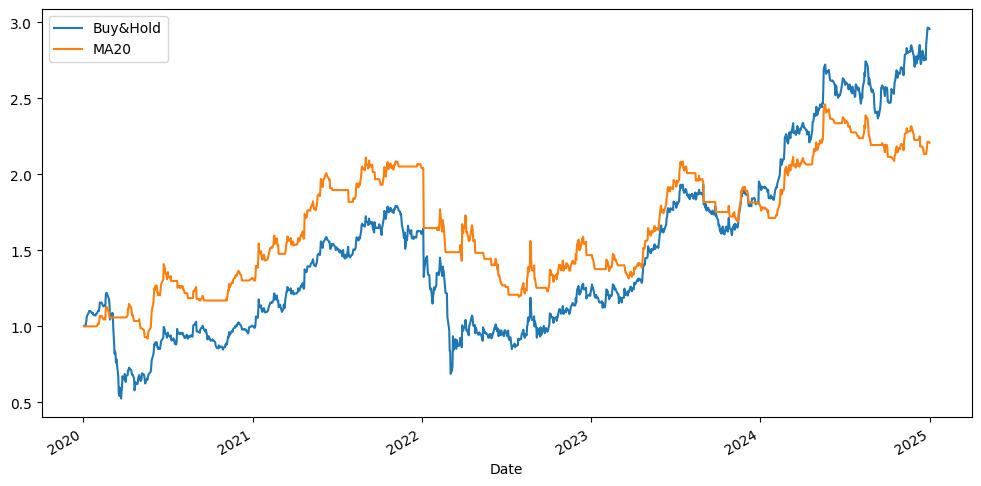

In [162]:
comparison=pd.DataFrame({
    "Buy&Hold":(1+halyk["Return"]).cumprod(),
    "MA20":(1+halyk["Strategy20"]).cumprod()
})
comparison.plot(figsize=(12,6))

<Axes: xlabel='Date'>

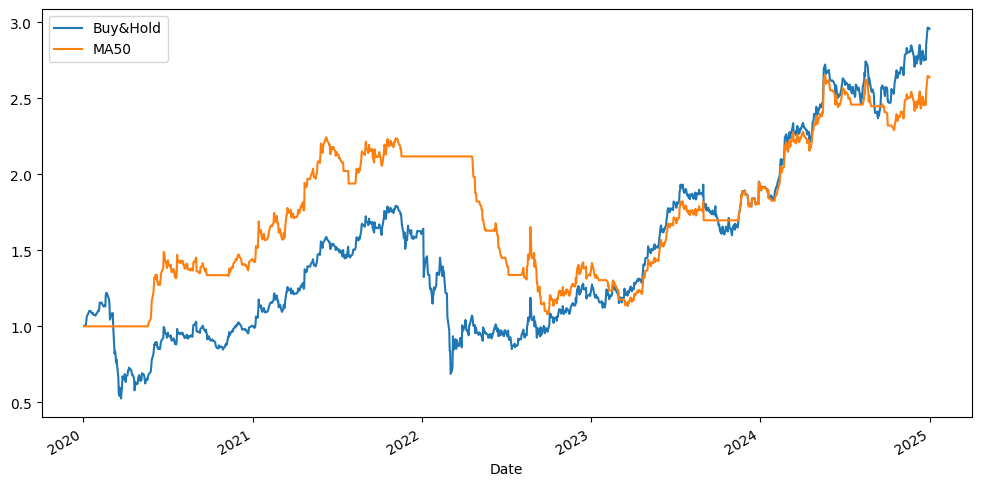

In [163]:
comparison=pd.DataFrame({
    "Buy&Hold":(1+halyk["Return"]).cumprod(),
    "MA50":(1+halyk["Strategy50"]).cumprod()
})
comparison.plot(figsize=(12,6))

In [164]:
kap["MA20"]=kap[("Close","KAP.IL")].rolling(20).mean()

In [165]:
kap["Signal20"]=0
kap.loc[kap[("Close","KAP.IL")]>kap["MA20"],"Signal20"]=1

In [166]:
kap["Strategy20"]=kap["Signal20"].shift(1)*kap["Return"]

In [167]:
kap["Strategy20"].mean()

np.float64(0.00016299378109875092)

In [168]:
kap["Strategy20"].std()

np.float64(0.020437662935532622)

In [169]:
kap["Strategy20"].mean()/kap["Strategy20"].std()

np.float64(0.007975167298378931)

In [170]:
kap["MA50"]=kap[("Close","KAP.IL")].rolling(50).mean()

In [171]:
kap["Signal50"]=0
kap.loc[kap[("Close","KAP.IL")]>kap["MA50"],"Signal50"]=1

In [172]:

kap["Strategy50"]=kap["Signal50"].shift(1)*kap["Return"]

In [173]:

kap["Strategy50"].mean()

np.float64(0.0005442575639130335)

In [174]:
kap["Strategy50"].std()

np.float64(0.02058145250410888)

In [175]:
kap["Strategy50"].mean()/kap["Strategy50"].std()

np.float64(0.026444079386738033)

<Axes: xlabel='Date'>

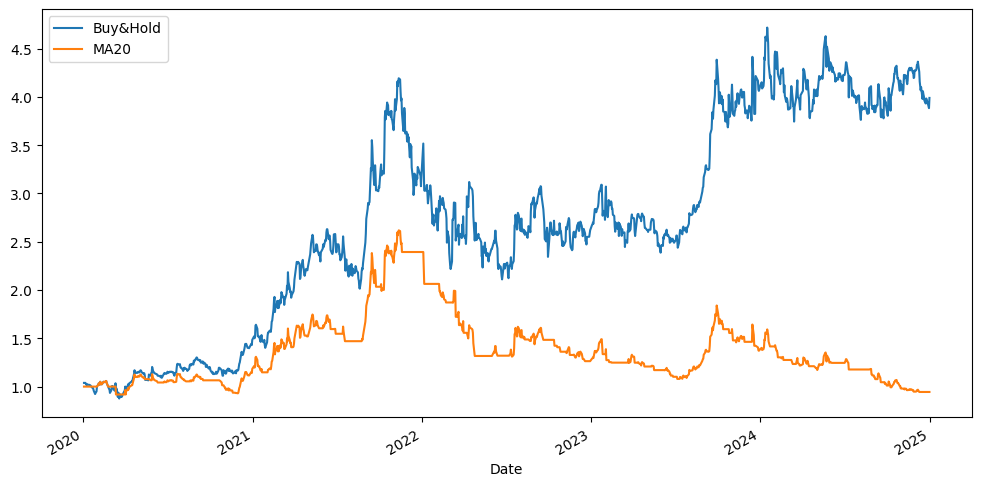

In [176]:

comparison=pd.DataFrame({
    "Buy&Hold":(1+kap["Return"]).cumprod(),
    "MA20":(1+kap["Strategy20"]).cumprod()
})
comparison.plot(figsize=(12,6))

<Axes: xlabel='Date'>

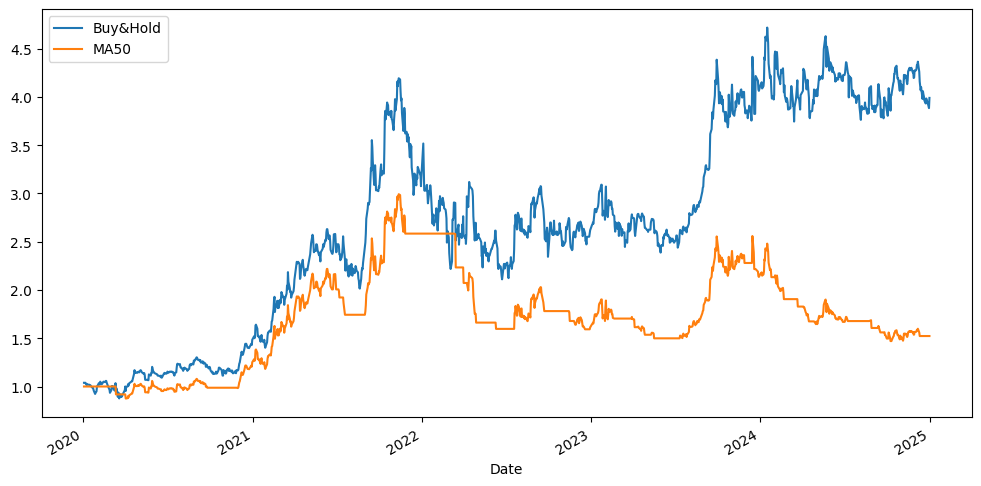

In [177]:
comparison=pd.DataFrame({
    "Buy&Hold":(1+kap["Return"]).cumprod(),
    "MA50":(1+kap["Strategy50"]).cumprod()
})
comparison.plot(figsize=(12,6))

In [178]:
matched_start="2024-01-19"
matched_end="2024-12-31"

In [179]:
combined_returns=pd.concat(
    [
        apple["Return"],
        msft["Return"],
        nvda["Return"],
        kaspi["Return"],
        halyk["Return"],
        kap["Return"]
    ],
    axis=1,
    keys=["AAPL","MSFT","NVDA","KSPI","HSBK.IL","KAP.IL"]
)
matched_returns=combined_returns.dropna()
print(matched_returns.index.min())
print(matched_returns.index.max())

2024-01-22 00:00:00
2024-12-31 00:00:00


In [180]:
matched_returns=combined_returns.dropna()
matched_start=matched_returns.index.min()
matched_end=matched_returns.index.max()
print("Matched sample:",matched_start,"to",matched_end)
print("Number of observations:",len(matched_returns))

Matched sample: 2024-01-22 00:00:00 to 2024-12-31 00:00:00
Number of observations: 235


In [181]:
us_matched=matched_returns[["AAPL","MSFT","NVDA"]]
kz_matched=matched_returns[["KSPI","HSBK.IL","KAP.IL"]]
us_portfolio_matched=us_matched.mean(axis=1)
kz_portfolio_matched=kz_matched.mean(axis=1)
print("US observations:",len(us_portfolio_matched))
print("KZ observations:",len(kz_portfolio_matched))

US observations: 235
KZ observations: 235


In [287]:
import numpy as np
import pandas as pd
TRADING_DAYS=252
ANNUAL_RF=0.0497

daily_rf=(1+ANNUAL_RF)**(1/TRADING_DAYS)-1

def individual_stock_metrics(stock,name):
    returns=stock["Return"]
    if isinstance(returns,pd.DataFrame):
        returns=returns.iloc[:,0]
    returns=returns.dropna()
    mean_daily_return=returns.mean()
    annualized_return=mean_daily_return*TRADING_DAYS
    annualized_volatility=returns.std()*np.sqrt(TRADING_DAYS)

    excess_returns=returns-daily_rf

    sharpe_ratio=(
        excess_returns.mean()
        /excess_returns.std()
        *np.sqrt(TRADING_DAYS)
    )
    return{
        "Stock":name,
        "Start Date:":returns.index.min().date(),
        "End Date":returns.index.max().date(),
        "Observations":len(returns),
        "Mean Daily Return":mean_daily_return,
        "Annualized Arithmetic Return":annualized_return,
        "Annualized Volatility":annualized_volatility,
        "Formal Sharpe Ratio":sharpe_ratio
    }
kz_individual_metrics=pd.DataFrame([
    individual_stock_metrics(kaspi,"KSPI"),
    individual_stock_metrics(halyk,"HSBK.IL"),
    individual_stock_metrics(kap,"KAP.IL")
])
kz_individual_metrics

,Stock,Start Date:,End Date,Observations,Mean Daily Return,Annualized Arithmetic Return,Annualized Volatility,Formal Sharpe Ratio
0,KSPI,2024-01-22,2024-12-31,239,0.000526,0.132522,0.397960,0.211108
1,HSBK.IL,2020-01-03,2024-12-31,1261,0.001232,0.310565,0.432082,0.606495
2,KAP.IL,2020-01-03,2024-12-31,1261,0.001508,0.379920,0.456791,0.725521


In [182]:
print("U.S. Technology Portfolio")
print("Mean Daily Return:", us_portfolio_matched.mean())
print("Daily Volatility:", us_portfolio_matched.std())

print()

print("Kazakhstan-related Portfolio")
print("Mean Daily Return:", kz_portfolio_matched.mean())
print("Daily Volatility:", kz_portfolio_matched.std())


U.S. Technology Portfolio
Mean Daily Return: 0.0018595772089377803
Daily Volatility: 0.01594914315418177

Kazakhstan-related Portfolio
Mean Daily Return: 0.0007918436232103256
Daily Volatility: 0.013221592652606475


In [183]:
import numpy as np
TRADING_DAYS=252
us_annual_return=us_portfolio_matched.mean()*TRADING_DAYS
kz_annual_return=kz_portfolio_matched.mean()*TRADING_DAYS

us_annual_vol=us_portfolio_matched.std()*np.sqrt(TRADING_DAYS)
kz_annual_vol=kz_portfolio_matched.std()*np.sqrt(TRADING_DAYS)

print("U.S. Technology Portfolio")
print("Annualized Return:",us_annual_return)
print("Annualized Volatility:",us_annual_vol)

print()

print("Kazakhstan-related Portfolio")
print("Annualized Return:",kz_annual_return)
print("Annualized Volatility:",kz_annual_vol)


U.S. Technology Portfolio
Annualized Return: 0.4686134566523206
Annualized Volatility: 0.2531847984631996

Kazakhstan-related Portfolio
Annualized Return: 0.19954459304900204
Annualized Volatility: 0.20988627656997325


In [184]:
us_sharpe_zero_rf=us_annual_return/ us_annual_vol
kz_sharpe_zero_rf=kz_annual_return/ kz_annual_vol

print("U.S. Sharp (Rf=0):", us_sharpe_zero_rf)
print("Kazakhstan-related Sharpe (Rf=0):",kz_sharpe_zero_rf)

U.S. Sharp (Rf=0): 1.8508751690336323
Kazakhstan-related Sharpe (Rf=0): 0.9507272047988168


In [185]:
us_wealth=(1+us_portfolio_matched).cumprod()
kz_wealth=(1+kz_portfolio_matched).cumprod()

us_peak=us_wealth.cummax()
kz_peak=kz_wealth.cummax()

us_drawdown=us_wealth/us_peak-1
kz_drawdown=kz_wealth/kz_peak-1

us_max_drawdown=us_drawdown.min()
kz_max_drawdown=kz_drawdown.min()

print("U.S. Maximum Drawdown:",us_max_drawdown)
print("Kazakhstan_related Maximum Drawdown:",kz_max_drawdown)


U.S. Maximum Drawdown: -0.16991635347095446
Kazakhstan_related Maximum Drawdown: -0.12315893486742646


In [186]:
us_corr_matched=us_matched.corr()
kz_corr_matched=kz_matched.corr()

print("U.S. Technology Correlation Matrix")
display(us_corr_matched.round(3))

print("\nKazakhstan-related Correlation Matrix")
display(kz_corr_matched.round(3))

U.S. Technology Correlation Matrix


,AAPL,MSFT,NVDA
AAPL,1.000,0.474,0.251
MSFT,0.474,1.000,0.447
NVDA,0.251,0.447,1.000



Kazakhstan-related Correlation Matrix


,KSPI,HSBK.IL,KAP.IL
KSPI,1.000,0.10,0.086
HSBK.IL,0.100,1.00,0.160
KAP.IL,0.086,0.16,1.000


In [187]:
us_avg_corr=(
    us_corr_matched.loc["AAPL","MSFT"]+
    us_corr_matched.loc["AAPL","NVDA"]+
    us_corr_matched.loc["MSFT","NVDA"]
)/3
kz_avg_corr=(
    kz_corr_matched.loc["KSPI","HSBK.IL"]+
    kz_corr_matched.loc["KSPI","KAP.IL"]+
    kz_corr_matched.loc["HSBK.IL","KAP.IL"]
)/3
print("U.S average pairwise correlation:",us_avg_corr)
print("Kazakhstan-related average pairwise correlation:",kz_avg_corr)

U.S average pairwise correlation: 0.39067731182201393
Kazakhstan-related average pairwise correlation: 0.11562686517980603


In [188]:
import numpy as np

TRADING_DAYS=252
weights=np.array([1/3,1/3,1/3])

us_individual_vol=us_matched.std()*np.sqrt(TRADING_DAYS)
kz_individual_vol=kz_matched.std()*np.sqrt(TRADING_DAYS)

us_portfolio_vol=us_portfolio_matched.std()*np.sqrt(TRADING_DAYS)
kz_portfolio_vol=kz_portfolio_matched.std()*np.sqrt(TRADING_DAYS)

us_div_ratio=np.dot(weights,us_individual_vol)/us_portfolio_vol
kz_div_ratio=np.dot(weights,kz_individual_vol)/kz_portfolio_vol

print("U.S. individual annualized volatility:")
print(us_individual_vol)

print("\nKazakhstan-related individual annualized volatility:")
print(kz_individual_vol)

print("\nU.S. Diversification Ration:",us_div_ratio)
print("Kazakhstan-related Diversification Ratio:",kz_div_ratio)



U.S. individual annualized volatility:
AAPL    0.225870
MSFT    0.202113
NVDA    0.533653
dtype: float64

Kazakhstan-related individual annualized volatility:
KSPI       0.400147
HSBK.IL    0.225693
KAP.IL     0.344411
dtype: float64

U.S. Diversification Ration: 1.2660543942669082
Kazakhstan-related Diversification Ratio: 1.540915594011595


In [189]:
rolling_window=30
TRADING_DAYS=252

us_rolling_vol=(
    us_portfolio_matched.rolling(window=rolling_window).std()*np.sqrt(TRADING_DAYS))
kz_rolling_vol=(
    kz_portfolio_matched.rolling(window=rolling_window).std()*np.sqrt(TRADING_DAYS))
print("US rolling volatility:")
print(us_rolling_vol.dropna().head())
print("\nKazakhstan-related rolling volatility:")
print(kz_rolling_vol.dropna().head())

US rolling volatility:
Date
2024-03-04    0.255137
2024-03-05    0.261788
2024-03-06    0.262122
2024-03-07    0.266204
2024-03-08    0.273069
dtype: float64

Kazakhstan-related rolling volatility:
Date
2024-03-04    0.224185
2024-03-05    0.207063
2024-03-06    0.208683
2024-03-07    0.208838
2024-03-08    0.203008
dtype: float64


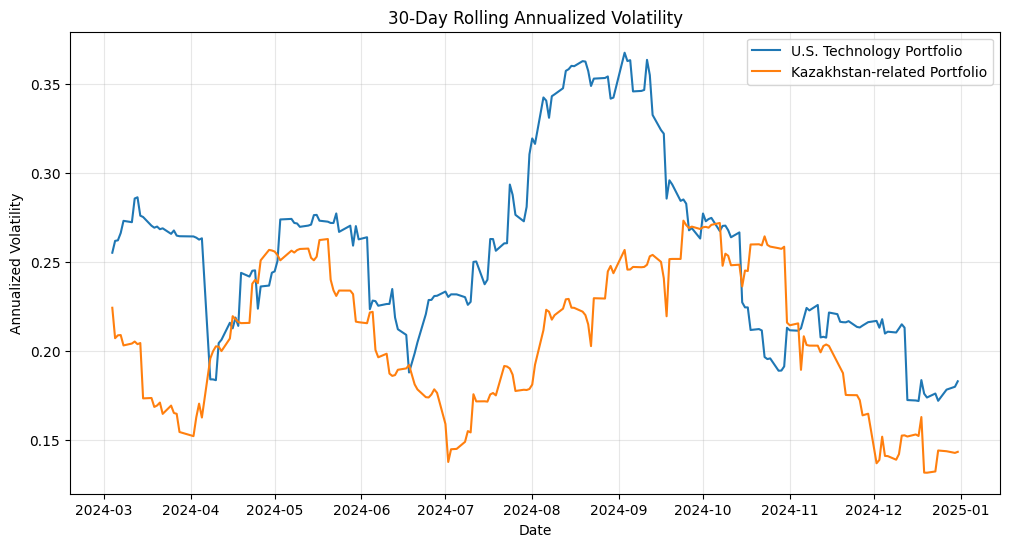

In [190]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(us_rolling_vol.index,us_rolling_vol,label="U.S. Technology Portfolio")
plt.plot(kz_rolling_vol.index,kz_rolling_vol,label="Kazakhstan-related Portfolio")
plt.title("30-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [191]:
print(us_rolling_vol.dropna().shape)
print(kz_rolling_vol.dropna().shape)

(206,)
(206,)


In [192]:
print("US Mean:",float(us_rolling_vol.mean()))
print("US Min:",float(us_rolling_vol.min()))
print("US Max:",float(us_rolling_vol.max()))

print("KZ Mean:",float(kz_rolling_vol.mean()))
print("KZ Min:",float(kz_rolling_vol.min()))
print("KZ Max:",float(kz_rolling_vol.max()))

US Mean: 0.25538951394736054
US Min: 0.171739282594873
US Max: 0.36761636079583093
KZ Mean: 0.20772170449252694
KZ Min: 0.13141326191688674
KZ Max: 0.27317657967204


U.S. Technology
Mean: 0.396520666303227
Min; 0.1257265279849131
Max: 0.6422660950151532

Kazakhstan-related
Mean: 0.12855421763394206
Min: -0.12561019555348632
Max: 0.40070053477668494


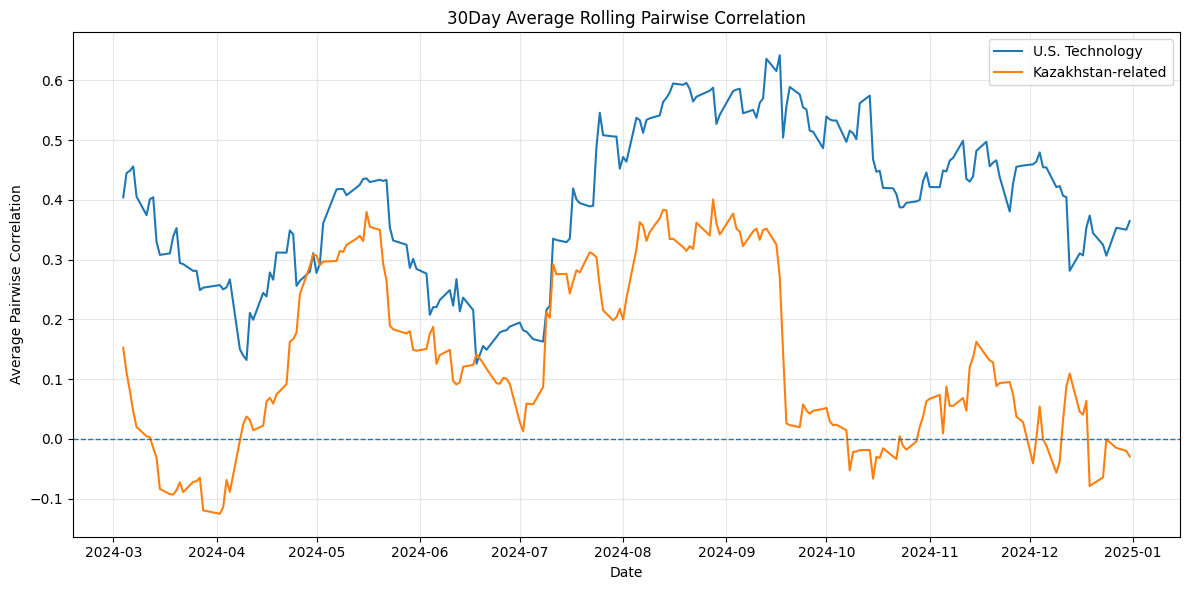

In [193]:
import pandas as pd
import matplotlib.pyplot as plt

ROLLING_WINDOW=30

us_rolling_corr=pd.DataFrame({
    "AAPL-MSFT":us_matched["AAPL"].rolling(ROLLING_WINDOW).corr(
        us_matched["MSFT"]
    ),
    "AAPL-NVDA":us_matched["AAPL"].rolling(ROLLING_WINDOW).corr(
        us_matched["NVDA"]
    ),
    "MSFT-NVDA":us_matched["MSFT"].rolling(ROLLING_WINDOW).corr(
        us_matched["NVDA"]
    )
})

kz_rolling_corr=pd.DataFrame({
    "KSPI-HSBK.IL":kz_matched["KSPI"].rolling(ROLLING_WINDOW).corr(
        kz_matched["HSBK.IL"]
        ),
    "KSPI-KAP.IL":kz_matched["KSPI"].rolling(ROLLING_WINDOW).corr(
        kz_matched["KAP.IL"]
    ),
    "HSBK.IL-KAP.IL":kz_matched["HSBK.IL"].rolling(ROLLING_WINDOW).corr(
        kz_matched["KAP.IL"]
        )
        })

us_avg_rolling_corr=us_rolling_corr.mean(axis=1)
kz_avg_rolling_corr=kz_rolling_corr.mean(axis=1)

print("U.S. Technology")
print("Mean:", us_avg_rolling_corr.mean())
print("Min;",us_avg_rolling_corr.min())
print("Max:",us_avg_rolling_corr.max())

print("\nKazakhstan-related")
print("Mean:",kz_avg_rolling_corr.mean())
print("Min:",kz_avg_rolling_corr.min())
print("Max:",kz_avg_rolling_corr.max())

plt.figure(figsize=(12,6))

plt.plot(
    us_avg_rolling_corr.index,
    us_avg_rolling_corr,
    label="U.S. Technology"
)
plt.plot(
    kz_avg_rolling_corr.index,
    kz_avg_rolling_corr,
    label="Kazakhstan-related"
)
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)
plt.title("30Day Average Rolling Pairwise Correlation")
plt.xlabel("Date")
plt.ylabel("Average Pairwise Correlation")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()



In [194]:
#Cumulative Wealth-Matched Sample

us_wealth=(1+us_portfolio_matched).cumprod()
kz_wealth=(1+kz_portfolio_matched).cumprod()

print("U.S. Final Wealth:",us_wealth.iloc[-1])
print("KZ Final Wealth:",kz_wealth.iloc[-1])

print("U.S. Cumulative Return:",us_wealth.iloc[-1]-1)
print("KZ Cumulative Return:",kz_wealth.iloc[-1]-1)


U.S. Final Wealth: 1.5021401917072439
KZ Final Wealth: 1.18010769321946
U.S. Cumulative Return: 0.5021401917072439
KZ Cumulative Return: 0.18010769321946007


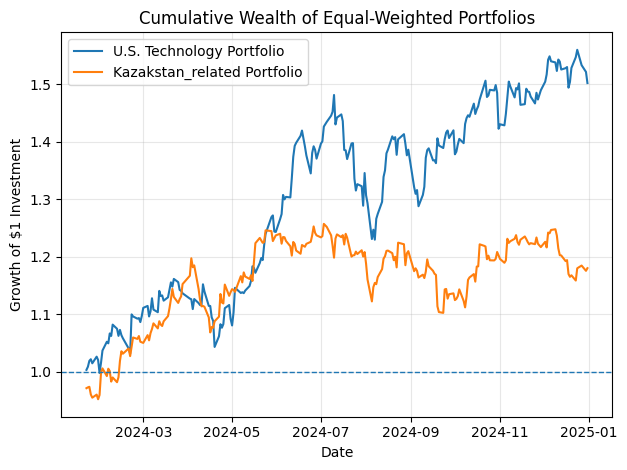

In [195]:
import matplotlib.pyplot as plt
plt.plot(
    us_wealth.index,
    us_wealth,
    label="U.S. Technology Portfolio"
)
plt.plot(
    kz_wealth.index,
    kz_wealth,
    label="Kazakstan_related Portfolio"
)
plt.axhline(
    y=1,
    linestyle="--",
    linewidth=1
)

plt.title("Cumulative Wealth of Equal-Weighted Portfolios")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [196]:
#Drawdown Analysis-Matched Simple
#Cumulative wealth
us_wealth=(1+us_portfolio_matched).cumprod()
kz_wealth=(1+kz_portfolio_matched).cumprod()

us_peak=us_wealth.cummax()
kz_peak=kz_wealth.cummax()

us_drawdown=us_wealth/us_peak-1
kz_drawdown=kz_wealth/kz_peak-1

us_mdd=us_drawdown.min()
kz_mdd=kz_drawdown.min()

print("US Maximum Drawdown:",us_mdd)
print("KZ Maximum Drawdown:",kz_mdd)

US Maximum Drawdown: -0.16991635347095446
KZ Maximum Drawdown: -0.12315893486742646


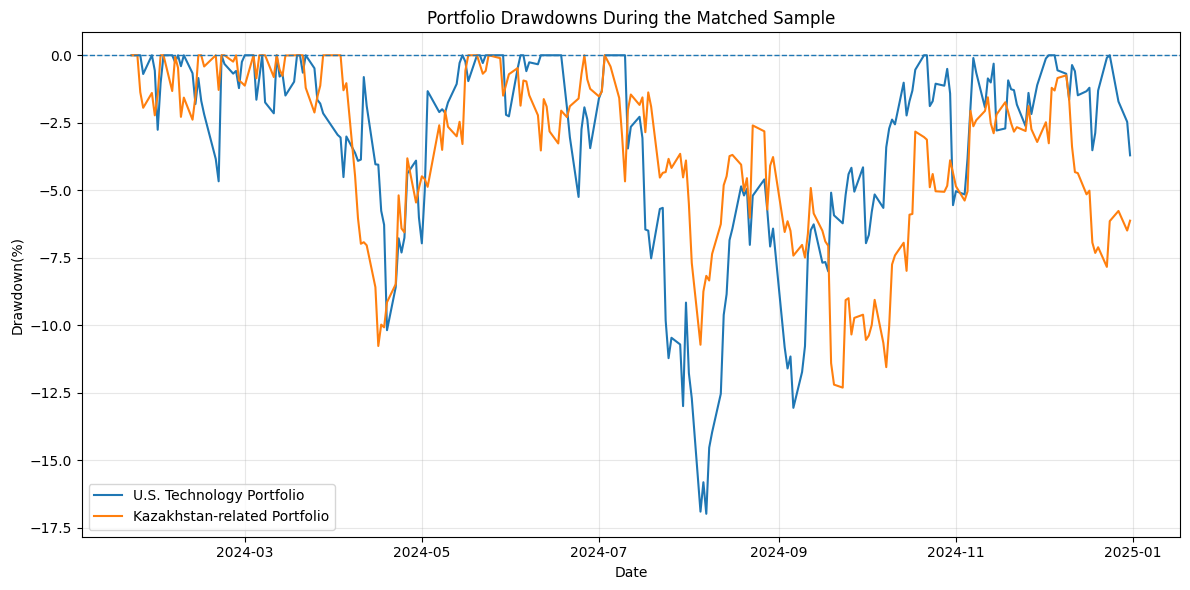

In [197]:
#Plot Drawdown Curves
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(
    us_drawdown.index,
    us_drawdown*100,
    label="U.S. Technology Portfolio"
)
plt.plot(
    kz_drawdown.index,
    kz_drawdown*100,
    label="Kazakhstan-related Portfolio"
)
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("Portfolio Drawdowns During the Matched Sample")
plt.xlabel("Date")
plt.ylabel("Drawdown(%)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [198]:
us_mdd_date=us_drawdown.idxmin()
kz_mdd_date=kz_drawdown.idxmin()
print("U.S. MDD Date:",us_mdd_date)
print("KZ MDD Date:",kz_mdd_date)

U.S. MDD Date: 2024-08-07 00:00:00
KZ MDD Date: 2024-09-23 00:00:00


In [199]:
#Formal Sharpe Ratio Function
import numpy as np
TRADING_DAYS=252
def annualized_sharpe(returns,annual_rf):

    daily_rf=(1+annual_rf)**(1/TRADING_DAYS)-1
    excess_returns=returns-daily_rf
    sharpe=(
       excess_returns.mean()
       /excess_returns.std()
       *np.sqrt(TRADING_DAYS)
)
    return sharpe

In [200]:
rf_test=0.00

us_sharpe_test=annualized_sharpe(
    us_portfolio_matched,
    rf_test
)
kz_sharpe_test=annualized_sharpe(
    kz_portfolio_matched,
    rf_test
)
print("US Sharpe(Rf=0):",us_sharpe_test)
print("KZ Sharpe(Rf=0):",kz_sharpe_test)

US Sharpe(Rf=0): 1.8508751690336325
KZ Sharpe(Rf=0): 0.9507272047988168


In [201]:

import numpy as np

TRADING_DAYS=252
ANNUAL_RF=0.0497

daily_rf=(1+ANNUAL_RF)**(1/TRADING_DAYS)-1

us_excess_return=us_portfolio_matched-daily_rf
kz_excess_return=kz_portfolio_matched-daily_rf

us_sharpe=(
    us_excess_return.mean()
    /us_excess_return.std()
    *np.sqrt(TRADING_DAYS)
)
kz_sharpe=(
    kz_excess_return.mean()
    /kz_excess_return.std()
    *np.sqrt(TRADING_DAYS)
)

print("Annual Risk-Free Rate:",ANNUAL_RF)
print("Daily Risk_Free Rate:",daily_rf)

print("US Formal Sharp Ratio:",us_sharpe)
print("KZ Formal Sharp Ratio:",kz_sharpe)

Annual Risk-Free Rate: 0.0497
Daily Risk_Free Rate: 0.00019249633877160832
US Formal Sharp Ratio: 1.6592796322364418
KZ Formal Sharp Ratio: 0.7196064370993001


In [202]:
def ma_backtest(price,returns,window):

    ma=price.rolling(window=window).mean()

    signal=(price>ma).astype(int)
    position=signal.shift(1)
    strategy_return=position*returns
    result=strategy_return.dropna()
    return result

In [203]:
print(apple.columns)
print(msft.columns)
print(nvda.columns)
print(kaspi.columns)
print(halyk.columns)
print(kap.columns)


MultiIndex([(             'Close', 'AAPL'),
            (              'High', 'AAPL'),
            (               'Low', 'AAPL'),
            (              'Open', 'AAPL'),
            (            'Volume', 'AAPL'),
            (            'Return',     ''),
            (              'MA50',     ''),
            (            'Signal',     ''),
            (   'Strategy_Return',     ''),
            (           'BuyHold',     ''),
            (          'Strategy',     ''),
            (              'MA20',     ''),
            (          'Signal20',     ''),
            ( 'Strategy20_Return',     ''),
            (          'Signal50',     ''),
            ( 'Strategy50_Return',     ''),
            (             'MA200',     ''),
            (         'Signal200',     ''),
            ('Strategy200_Return',     '')],
           names=['Price', 'Ticker'])
MultiIndex([(             'Close', 'MSFT'),
            (              'High', 'MSFT'),
            (               'Low', 'M

In [204]:
def add_ma_strategy(df,windows=(20,50,100)):
    close=df["Close"]
    if isinstance(close,pd.DataFrame):
        close=close.iloc[:,0]
        returns =df["Return"]
    if usunstance(returns,pd.DataFrame):
        returns=returns.iloc[:,0]
        for window in window:
            ma=close.rolling(window=window).mean()
            signal=(close>ma).astype(int)
            df[f"MA{window}"]=signal
            df[f"Strategy_{window}_Return"]=(signal.shify(1)*returns)
            return df
        

In [205]:
print(type(apple["Close"]))
print(apple["Close"].shape)
print(apple.columns)

<class 'pandas.core.frame.DataFrame'>
(1258, 1)
MultiIndex([(             'Close', 'AAPL'),
            (              'High', 'AAPL'),
            (               'Low', 'AAPL'),
            (              'Open', 'AAPL'),
            (            'Volume', 'AAPL'),
            (            'Return',     ''),
            (              'MA50',     ''),
            (            'Signal',     ''),
            (   'Strategy_Return',     ''),
            (           'BuyHold',     ''),
            (          'Strategy',     ''),
            (              'MA20',     ''),
            (          'Signal20',     ''),
            ( 'Strategy20_Return',     ''),
            (          'Signal50',     ''),
            ( 'Strategy50_Return',     ''),
            (             'MA200',     ''),
            (         'Signal200',     ''),
            ('Strategy200_Return',     '')],
           names=['Price', 'Ticker'])


In [206]:
import pandas as pd
import numpy as np

TRADING_DAYS=252
ANNUAL_RF=0.0497

def strategy_metrics(returns):
    returns=returns.dropna()

    cumulative_return=(1+returns).prod()-1

    annual_return=returns.mean()*TRADING_DAYS

    annual_vol=returns.std()*np.sqrt(TRADING_DAYS)

    daily_rf=(1+ANNUAL_RF)**(1/TRADING_DAYS)-1

    excess_returns=returns-daily_rf
    sharpe=(
        excess_returns.mean()/excess_returns.std()
        *np.sqrt(TRADING_DAYS)
)
    wealth=(1+returns).cumprod()
    peak=wealth.cummax()
    drawdown=wealth/peak-1
    max_drawdown=drawdown.min()
    return{
        "Cumulative Return":cumulative_return,
        "Annualized Return":annual_return,
        "Annualized Volatility":annual_vol,
        "Sharpe Ratio":sharpe,
        "Maximum Drawdown":max_drawdown
}

In [207]:
print(apple.columns.tolist())

[('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL'), ('Return', ''), ('MA50', ''), ('Signal', ''), ('Strategy_Return', ''), ('BuyHold', ''), ('Strategy', ''), ('MA20', ''), ('Signal20', ''), ('Strategy20_Return', ''), ('Signal50', ''), ('Strategy50_Return', ''), ('MA200', ''), ('Signal200', ''), ('Strategy200_Return', '')]


In [208]:
close=apple["Close"].squeeze()
returns=apple["Return"].squeeze()

for window in(50,100,200):
    apple[f"MA{window}"]=close.rolling(window).mean()
    apple[f"Signal{window}"]=(close>apple[f"MA{window}"]).astype(int)
    apple[f"Strategy{window}_Return"]= (
        apple[f"Signal{window}"].shift(1)*returns
        )  

In [209]:
print(apple.columns.tolist())

[('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL'), ('Return', ''), ('MA50', ''), ('Signal', ''), ('Strategy_Return', ''), ('BuyHold', ''), ('Strategy', ''), ('MA20', ''), ('Signal20', ''), ('Strategy20_Return', ''), ('Signal50', ''), ('Strategy50_Return', ''), ('MA200', ''), ('Signal200', ''), ('Strategy200_Return', ''), ('MA100', ''), ('Signal100', ''), ('Strategy100_Return', '')]


In [210]:
apple_results=pd.DataFrame({
    "Buy&Hold":strategy_metrics(apple["Return"].squeeze()),
    "MA20":strategy_metrics(apple["Strategy20_Return"].squeeze()),
    "MA50":strategy_metrics(apple["Strategy50_Return"].squeeze()),
    "MA100":strategy_metrics(apple["Strategy100_Return"].squeeze()),
    "MA200":strategy_metrics(apple["Strategy200_Return"].squeeze())
}).T
apple_results

,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Buy&Hold,2.440024,0.297892,0.316786,0.787227,-0.314273
MA20,2.452347,0.270018,0.207857,1.065681,-0.224745
MA50,1.269008,0.185788,0.207571,0.661361,-0.295951
MA100,1.190169,0.180755,0.217312,0.608552,-0.263311
MA200,0.679489,0.123735,0.198974,0.378067,-0.311870


In [211]:
def add_ma_columns(df,windows=(20,50,100,200)):
    close=df["Close"].squeeze()
    returns=df["Close"].squeeze()

    for window in windows:
        ma=close.rolling(window).mean()
        signal=(close>ma).astype(int)

        df[f"MA{window}"]=ma
        df[f"Signal{window}"]=signal
        df[f"Strategy{window}_Return"]=signal.shift(1)*returns
        return df

In [212]:
msft=add_ma_columns(msft)
nvda=add_ma_columns(nvda)
kaspi=add_ma_columns(kaspi)
halyk=add_ma_columns(halyk)
kap=add_ma_columns(kap)

In [213]:
print(msft.columns.tolist())

[('Close', 'MSFT'), ('High', 'MSFT'), ('Low', 'MSFT'), ('Open', 'MSFT'), ('Volume', 'MSFT'), ('Return', ''), ('MA20', ''), ('Signal20', ''), ('Strategy20_Return', ''), ('MA50', ''), ('Signal50', ''), ('Strategy50_Return', ''), ('MA100', ''), ('Signal100', ''), ('Strategy100_Return', ''), ('MA200', ''), ('Signal200', ''), ('Strategy200_Return', '')]


In [214]:
print(kap.columns.tolist())

[('Close', 'KAP.IL'), ('High', 'KAP.IL'), ('Low', 'KAP.IL'), ('Open', 'KAP.IL'), ('Volume', 'KAP.IL'), ('Return', ''), ('MA20', ''), ('Signal20', ''), ('Strategy20', ''), ('MA50', ''), ('Signal50', ''), ('Strategy50', ''), ('Strategy20_Return', '')]


In [215]:
print(halyk.columns.tolist())

[('Close', 'HSBK.IL'), ('High', 'HSBK.IL'), ('Low', 'HSBK.IL'), ('Open', 'HSBK.IL'), ('Volume', 'HSBK.IL'), ('Return', ''), ('MA20', ''), ('Signal20', ''), ('Strategy20', ''), ('MA50', ''), ('Signal50', ''), ('Strategy50', ''), ('Strategy20_Return', '')]


In [216]:
print(nvda.columns.tolist())

[('Close', 'NVDA'), ('High', 'NVDA'), ('Low', 'NVDA'), ('Open', 'NVDA'), ('Volume', 'NVDA'), ('Return', ''), ('MA20', ''), ('Signal20', ''), ('Strategy20_Return', ''), ('MA50', ''), ('Signal50', ''), ('Strategy50_Return', ''), ('MA100', ''), ('Signal100', ''), ('Strategy100_Return', ''), ('MA200', ''), ('Signal200', ''), ('Strategy200_Return', '')]


In [217]:
print(kaspi.columns.tolist())

[('Close', 'KSPI'), ('High', 'KSPI'), ('Low', 'KSPI'), ('Open', 'KSPI'), ('Volume', 'KSPI'), ('Return', ''), ('MA20', ''), ('Signal20', ''), ('Strategy20', ''), ('MA50', ''), ('Signal50', ''), ('Strategy50', ''), ('MA100', ''), ('Signal100', ''), ('Strategy100', ''), ('MA200', ''), ('Signal200', ''), ('Strategy200', ''), ('Strategy20_Return', '')]


In [218]:
for df in [msft,nvda,kaspi,halyk,kap]:
    close=df["Close"].squeeze()
    returns=df["Return"].squeeze()
    for window in[50,100,200]:
        ma=close.rolling(window).mean()
        signal=(close>ma).astype(int)

        df[f"MA{window}"]=ma
        df[f"Signal{window}"]=signal
        df[f"Strategy{window}_Return"]=signal.shift(1)*returns

In [219]:
print(msft.columns.tolist())

[('Close', 'MSFT'), ('High', 'MSFT'), ('Low', 'MSFT'), ('Open', 'MSFT'), ('Volume', 'MSFT'), ('Return', ''), ('MA20', ''), ('Signal20', ''), ('Strategy20_Return', ''), ('MA50', ''), ('Signal50', ''), ('Strategy50_Return', ''), ('MA100', ''), ('Signal100', ''), ('Strategy100_Return', ''), ('MA200', ''), ('Signal200', ''), ('Strategy200_Return', '')]


In [220]:
def make_strategy_results(df):
    return pd.DataFrame({
        "Buy&Hold":strategy_metrics(df["Return"].squeeze()),
        "MA20":strategy_metrics(df["Strategy20_Return"].squeeze()),
        "MA50":strategy_metrics(df["Strategy50_Return"].squeeze()),
        "MA100":strategy_metrics(df["Strategy100_Return"].squeeze()),
        "MA200":strategy_metrics(df["Strategy200_Return"].squeeze())
    }).T

In [221]:
msft["Return"]

Date
2020-01-02         NaN
2020-01-03   -0.012451
2020-01-06    0.002585
2020-01-07   -0.009118
2020-01-08    0.015929
                ...   
2024-12-24    0.009374
2024-12-26   -0.002777
2024-12-27   -0.017302
2024-12-30   -0.013239
2024-12-31   -0.007838
Name: Return, Length: 1258, dtype: float64

In [222]:
msft["Strategy20_Return"]=(msft["Signal20"].shift(1)*msft["Return"]
                          )

In [223]:
print(msft["Strategy20_Return"].describe())

count    1257.000000
mean        0.000201
std         0.012198
min        -0.077156
25%        -0.001903
50%         0.000000
75%         0.003133
max         0.074368
Name: Strategy20_Return, dtype: float64


In [224]:
stocks=[msft,nvda,kaspi,halyk,kap]
windows=[20,50,100,200]

for stock in stocks:
    for window in windows:
        stock[f"MA{window}"]=(
            stock["Close"].iloc[:,0].rolling(window).mean()
            if isinstance(stock["Close"],pd.DataFrame)
            else stock["Close"].rolling(window).mean()
        )
        
        close=(
            stock["Close"].iloc[:,0]
            if isinstance(stock["Close"],pd.DataFrame)
            else stock["Close"]
        )
        stock[f"Signal{window}"]=(
            close>stock[f"MA{window}"]
        ).astype(int)
        returns=(
            stock["Return"].iloc[:,0]
            if isinstance(stock["Return"],pd.DataFrame)
            else stock["Return"]
        )
        stock[f"Strategy{window}_Return"]=(
            stock[f"Signal{window}"].shift(1)*returns
        )

print("MA20/50/100/200 strategies recalculated successfully.")

MA20/50/100/200 strategies recalculated successfully.


In [225]:
for name,stock in{
    "MSFT":msft,
    "NVDA":nvda,
    "KSPI":kaspi,
    "HSBK":halyk,
    "KAP":kap
}.items():
    
    print("\n",name)

    for window in [20,50,100,200]:
       
        x=stock[f"Strategy{window}_Return"]
        
        if isinstance(x,pd.DataFrame):
            x=x.iloc[:,0]
            
            print(
            f"MA{window}:mean={x.mean():.6f},"
            f"std={x.std():.6f},"
            f"max={x.max():.6f}"
            )


 MSFT

 NVDA

 KSPI

 HSBK

 KAP


In [226]:
print(msft["Strategy20_Return"].describe())

count    1257.000000
mean        0.000201
std         0.012198
min        -0.077156
25%        -0.001903
50%         0.000000
75%         0.003133
max         0.074368
Name: Strategy20_Return, dtype: float64


In [227]:
print("MSFT MA20:",msft["Strategy20_Return"].mean(),msft["Strategy20_Return"].std())
print("MSFT MA50:",msft["Strategy50_Return"].mean(),msft["Strategy50_Return"].std())
print("MSFT MA100:",msft["Strategy100_Return"].mean(),msft["Strategy100_Return"].std())
print("MSFT MA200:",msft["Strategy200_Return"].mean(),msft["Strategy200_Return"].std())

MSFT MA20: 0.00020102984639032458 0.012198477688204172
MSFT MA50: 0.00034572819392936726 0.01235099997882161
MSFT MA100: 0.00047313651474182255 0.012275596988589436
MSFT MA200: 0.00043430809609235863 0.01134753762494159


In [228]:
print("NVDA MA20:",nvda["Strategy20_Return"].mean(),nvda["Strategy20_Return"].std())
print("NVDA MA50:",nvda["Strategy50_Return"].mean(),nvda["Strategy50_Return"].std())
print("NVDA MA100:",nvda["Strategy100_Return"].mean(),nvda["Strategy100_Return"].std())
print("NVDA MA200:",nvda["Strategy200_Return"].mean(),nvda["Strategy200_Return"].std())

NVDA MA20: 0.0022164814799617875 0.024446064519360034
NVDA MA50: 0.0021217128020052643 0.025423547106345847
NVDA MA100: 0.0021408713273738046 0.02522956349841058
NVDA MA200: 0.002190359927159533 0.025558065082287824


In [229]:
print("KSPI MA20:",kaspi["Strategy20_Return"].mean(),kaspi["Strategy20_Return"].std())
print("KSPI MA50:",kaspi["Strategy50_Return"].mean(),kaspi["Strategy50_Return"].std())
print("KSPI MA100:",kaspi["Strategy100_Return"].mean(),kaspi["Strategy100_Return"].std())
print("KSPI MA200:",kaspi["Strategy200_Return"].mean(),kaspi["Strategy200_Return"].std())

KSPI MA20: 0.0003703529844685472 0.017409231447386393
KSPI MA50: -0.0012669739225253931 0.014119980801625086
KSPI MA100: -0.00027042659733024363 0.010304083869528895
KSPI MA200: -9.560353640346478e-05 0.0014779948055763993


In [230]:
print("HSBK.IL MA20:",halyk["Strategy20_Return"].mean(),halyk["Strategy20_Return"].std())
print("HSBK.IL MA50:",halyk["Strategy50_Return"].mean(),halyk["Strategy50_Return"].std())
print("HSBK.IL MA100:",halyk["Strategy100_Return"].mean(),halyk["Strategy100_Return"].std())
print("HSBK.IL MA200:",halyk["Strategy200_Return"].mean(),halyk["Strategy200_Return"].std())

HSBK.IL MA20: 0.000780611029974455 0.01744628028483234
HSBK.IL MA50: 0.0008946524785232708 0.015892488800180276
HSBK.IL MA100: 0.0010346686966357151 0.015631566295169586
HSBK.IL MA200: 0.001134005948238144 0.01513859910742599


In [231]:
print("KAP.IL MA20:",kap["Strategy20_Return"].mean(),kap["Strategy20_Return"].std())
print("KAP.IL MA50:",kap["Strategy50_Return"].mean(),kap["Strategy50_Return"].std())
print("KAP.IL MA100:",kap["Strategy100_Return"].mean(),kap["Strategy100_Return"].std())
print("KAP.IL MA200:",kap["Strategy200_Return"].mean(),kap["Strategy200_Return"].std())

KAP.IL MA20: 0.00016299378109875092 0.020437662935532622
KAP.IL MA50: 0.0005442575639130335 0.02058145250410888
KAP.IL MA100: 0.0003418775156934774 0.020819209737501957
KAP.IL MA200: 0.0004532632525941621 0.021611249884751462


In [232]:
def common_period_performance(stock):
    returns=stock["Return"]
    if isinstance(returns,pd.DataFrame):
        returns=returns.iloc[:,0]

    ma20=stock["Strategy20_Return"]
    ma50=stock["Strategy50_Return"]
    ma100=stock["Strategy100_Return"]
    ma200=stock["Strategy200_Return"]

    if isinstance(ma20,pd.DataFrame):
        ma20=ma20.iloc[:,0]
    if isinstance(ma50,pd.DataFrame):
        ma50=ma50.iloc[:,0]
    if isinstance(ma100,pd.DataFrame):
        ma100=ma100.iloc[:,0]
    if isinstance(ma200,pd.DataFrame):
        ma200=ma200.iloc[:,0]
        
    ma200_values=stock["MA200"]
    if isinstance(ma200_values,pd.DataFrame):
        ma200_values=ma200_values.iloc[:,0]
    start_date=ma200_values.first_valid_index()

    returns=returns.loc[start_date:]
    ma20=ma20.loc[start_date:]
    ma50=ma50.loc[start_date:]
    ma100=ma100.loc[start_date:]
    ma200=ma200.loc[start_date:]
    
    results={
        "Buy&Hold":strategy_metrics(returns),
        "MA20":strategy_metrics(ma20),
        "MA50":strategy_metrics(ma50),
        "MA100":strategy_metrics(ma100),
        "MA200":strategy_metrics(ma200)
        }
    table=pd.DataFrame(results).T
        
    return table ,start_date

        

In [233]:
msft_final, msft_start=common_period_performance(msft)
print("Microsoft Common start date:",msft_start)
display(msft_final)

Microsoft Common start date: 2020-10-15 00:00:00


,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Buy&Hold,0.979526,0.196437,0.260469,0.567928,-0.371485
MA20,0.071222,0.032267,0.178029,-0.091232,-0.409321
MA50,0.179060,0.056377,0.185497,0.042415,-0.228883
MA100,0.369545,0.092481,0.187894,0.234023,-0.222448
MA200,0.591922,0.129909,0.196243,0.414789,-0.304897


In [234]:
aapl_final, aapl_start=common_period_performance(apple)
print("Apple Common start date:",aapl_start)
display(aapl_final)

Apple Common start date: 2020-10-15 00:00:00


,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Buy&Hold,1.116783,0.214599,0.269021,0.617385,-0.309128
MA20,1.178824,0.202525,0.185565,0.829982,-0.195372
MA50,0.560101,0.123037,0.185572,0.401612,-0.292651
MA100,0.428427,0.104777,0.199795,0.281629,-0.263311
MA200,0.679489,0.146869,0.216764,0.453767,-0.311870


In [235]:
nvda_final, nvda_start=common_period_performance(nvda)
print("NVIDIA Common start date:",nvda_start)
display(nvda_final)

NVIDIA Common start date: 2020-10-15 00:00:00


,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Buy&Hold,8.554325,0.671994,0.522015,1.194381,-0.663351
MA20,5.228186,0.505573,0.378339,1.208082,-0.338639
MA50,4.345509,0.480214,0.407304,1.059909,-0.320002
MA100,5.139546,0.516797,0.415427,1.127245,-0.463694
MA200,9.471551,0.655172,0.441755,1.373301,-0.409907


In [236]:
kaspi_final, kaspi_start=common_period_performance(kaspi)
print("Kaspi Common start date:",kaspi_start)
display(kaspi_final)

Kaspi Common start date: 2024-11-01 00:00:00


/var/folders/b2/r5_27sb17dzgwp9jg08208fw0000gn/T/ipykernel_6537/2299440359.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  excess_returns.mean()/excess_returns.std()


,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Buy&Hold,-0.126458,-0.789599,0.286489,-2.925443,-0.167285
MA20,-0.045448,-0.271035,0.174004,-1.836417,-0.090061
MA50,-0.103232,-0.661228,0.124182,-5.715282,-0.103232
MA100,0.000000,0.000000,0.000000,-inf,0.000000
MA200,-0.022849,-0.140439,0.056647,-3.335515,-0.022849


In [237]:
halyk_final, halyk_start=common_period_performance(halyk)
print("Halyk Common start date:",halyk_start)
display(halyk_final)

Halyk Common start date: 2020-10-14 00:00:00


,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Buy&Hold,2.377947,0.368434,0.400285,0.799243,-0.616304
MA20,0.887857,0.189827,0.279719,0.505216,-0.434226
MA50,0.974245,0.193297,0.254377,0.569187,-0.517860
MA100,2.090820,0.299153,0.252526,0.992543,-0.365810
MA200,2.609103,0.338998,0.261626,1.110321,-0.336157


In [238]:
kap_final, kap_start=common_period_performance(kap)
print("Kazatoprom Common start date:",kap_start)
display(kap_final)

Kazatoprom Common start date: 2020-10-14 00:00:00


,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Buy&Hold,2.494236,0.408539,0.475519,0.757131,-0.496694
MA20,-0.113225,0.029230,0.340300,-0.056654,-0.639250
MA50,0.542378,0.160939,0.342113,0.328635,-0.508461
MA100,0.119710,0.088557,0.352932,0.113472,-0.653599
MA200,0.322670,0.135498,0.373668,0.232798,-0.702602


In [239]:
def strategy_with_costs(stock,window,cost_bps):
    returns=stock["Return"]
    if isinstance(returns,pd.DataFrame):
        returns=returns.iloc[:,0]

    signal=stock[f"Signal{window}"]
    if isinstance(signal,pd.DataFrame):
        signal=signal.iloc[:,0]
    ma200=stock["MA200"]
    if isinstance(ma200,pd.DataFrame):
        ma200=ma200.iloc[:,0]
    start_date=ma200.first_valid_index()

    position=signal.shift(1).fillna(0)
    
    returns=returns.loc[start_date:]
    position=position.loc[start_date:]

    turnover=position.diff().abs()
    
    turnover.iloc[0]=abs(position.iloc[0])

    cost=cost_bps/10000

    net_returns=position*returns-turnover*cost

    return net_returns, turnover
    
    

In [240]:
for cost in [0,10,25]:
    net_returns,turnover=strategy_with_costs(
        apple,
        20,
        cost
    )
    metrics=strategy_metrics(net_returns)

    print(f"Transaction Cost:{cost}bps")
    print(f"Cumulative Return:{metrics['Cumulative Return']:.4f}")
    print(f"Sharpe Ratio{metrics['Sharpe Ratio']:4f}")
    print(f"Total Position Changes:{turnover.sum():.0f}")
    print("-"*40)
    

Transaction Cost:0bps
Cumulative Return:1.1788
Sharpe Ratio0.829982
Total Position Changes:95
----------------------------------------
Transaction Cost:10bps
Cumulative Return:0.9819
Sharpe Ratio0.709118
Total Position Changes:95
----------------------------------------
Transaction Cost:25bps
Cumulative Return:0.7190
Sharpe Ratio0.526614
Total Position Changes:95
----------------------------------------


In [241]:
stocks_dict={
    "AAPL":apple,
    "MSFT":msft,
    "NVDA":nvda,
    "KSPI":kaspi,
    "HSBK":halyk,
    "KAP":kap
}
windows=[20,50,100,200]
cost_levels=[0,10,25]
transaction_cost_results=[]

for stock_name,stock in stocks_dict.items():
    for window in windows:
        for cost in cost_levels:
            net_returns,turnover=strategy_with_costs(
                stock,
                window,
                cost
            )
            metrics=strategy_metrics(net_returns)
            transaction_cost_results.append({
            "Stock":stock_name,
            "Strategy":f"MA{window}",
            "Cost (bps)":cost,
            "Cumulative Return":metrics["Cumulative Return"],
            "Annualized Return":metrics["Annualized Return"],
            "Annualized Volatility":metrics["Annualized Volatility"],
            "Sharpe Ratio":metrics["Sharpe Ratio"],
            "Maximum Drawdown":metrics["Maximum Drawdown"],
            "Position Changes":turnover.sum()
        })
transaction_cost_table=pd.DataFrame(transaction_cost_results)
transaction_cost_table

/var/folders/b2/r5_27sb17dzgwp9jg08208fw0000gn/T/ipykernel_6537/2299440359.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  excess_returns.mean()/excess_returns.std()


,Stock,Strategy,Cost (bps),Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Position Changes
0,AAPL,MA20,0,1.178824,0.202525,0.185565,0.829982,-0.195372,95.0
1,AAPL,MA20,10,0.981865,0.179919,0.185314,0.709118,-0.202622,95.0
2,AAPL,MA20,25,0.718995,0.146010,0.185146,0.526614,-0.213389,95.0
3,AAPL,MA50,0,0.560101,0.123037,0.185572,0.401612,-0.292651,65.0
4,AAPL,MA50,10,0.461735,0.107569,0.185754,0.317950,-0.308849,65.0
...,...,...,...,...,...,...,...,...,...
67,KAP,MA100,10,0.031522,0.069117,0.352950,0.058389,-0.669541,82.0
68,KAP,MA100,25,-0.088051,0.039959,0.353072,-0.024218,-0.692306,82.0
69,KAP,MA200,0,0.322670,0.135498,0.373668,0.232798,-0.702602,66.0
70,KAP,MA200,10,0.237980,0.119852,0.373786,0.190865,-0.716284,66.0


In [242]:
cost_summary=transaction_cost_table.pivot_table(
    index=["Stock","Strategy"],
    columns="Cost (bps)",
    values=["Cumulative Return","Sharpe Ratio"]
)
cost_summary=cost_summary.round(4)
cost_summary

Cumulative Return                 Sharpe Ratio                
Cost (bps)                    0       10      25           0       10      25
Stock Strategy                                                               
AAPL  MA100               0.4284  0.3574  0.2572       0.2816  0.2208  0.1296
      MA20                1.1788  0.9819  0.7190       0.8300  0.7091  0.5266
      MA200               0.6795  0.6380  0.5775       0.4538  0.4263  0.3849
      MA50                0.5601  0.4617  0.3255       0.4016  0.3180  0.1926
HSBK  MA100               2.0908  1.9661  1.7881       0.9925  0.9532  0.8942
      MA20                0.8879  0.6888  0.4286       0.5052  0.4106  0.2690
      MA200               2.6091  2.5765  2.5282       1.1103  1.1019  1.0892
      MA50                0.9742  0.8273  0.6269       0.5692  0.4968  0.3883
KAP   MA100               0.1197  0.0315 -0.0881       0.1135  0.0584 -0.0242
      MA20               -0.1132 -0.2414 -0.3999      -0.0567 -0.1653 -0.3281
      MA200               0.3227  0.2380  0.1209       0.2328  0.1909  0.1280
      MA50                0.5424  0.4295  0.2753       0.3286  0.2760  0.1969
KSPI  MA100               0.0000  0.0000  0.0000         -inf    -inf    -inf
      MA20               -0.0454 -0.0512 -0.0597      -1.8364 -2.0386 -2.3339
      MA200              -0.0228 -0.0248 -0.0278      -3.3355 -3.4041 -3.4872
      MA50               -0.1032 -0.1122 -0.1255      -5.7153 -6.2017 -6.8892
MSFT  MA100               0.3695  0.2885  0.1756       0.2340  0.1567  0.0408
      MA20                0.0712 -0.0668 -0.2414      -0.0912 -0.2758 -0.5522
      MA200               0.5919  0.5310  0.4438       0.4148  0.3674  0.2962
      MA50                0.1791  0.0754 -0.0634       0.0424 -0.0756 -0.2523
NVDA  MA100               5.1395  4.8690  4.4850       1.1272  1.1013  1.0622
      MA20                5.2282  4.5419  3.6505       1.2081  1.1346  1.0240
      MA200               9.4716  9.3378  9.1402       1.3733  1.3665  1.3563
      MA50                4.3455  3.9854  3.4897       1.0599  1.0192  0.9580

In [243]:
trade_summary=(
    transaction_cost_table[
        transaction_cost_table["Cost (bps)"]==0
    ][["Stock","Strategy","Position Changes"]]
    .sort_values(["Stock","Strategy"])
    .reset_index(drop=True)
)
trade_summary

,Stock,Strategy,Position Changes
0,AAPL,MA100,51.0
1,AAPL,MA20,95.0
2,AAPL,MA200,25.0
3,AAPL,MA50,65.0
4,HSBK,MA100,41.0
5,HSBK,MA20,111.0
6,HSBK,MA200,9.0
7,HSBK,MA50,77.0
8,KAP,MA100,82.0
9,KAP,MA20,156.0


In [244]:
cost_impact=(
    transaction_cost_table
    .pivot_table(
        index=["Stock","Strategy"],
        columns="Cost (bps)",
        values="Cumulative Return"
    )
    .reset_index()
)
cost_impact["Return Loss(0→25bps)"]=(
    cost_impact[0]-cost_impact[25]
)
trade_data=(
    transaction_cost_table[
        transaction_cost_table["Cost (bps)"]==0
        ][["Stock","Strategy","Position Changes"]]
)
cost_impact=cost_impact.merge(
    trade_data,
    on=["Stock","Strategy"]
)
cost_impact=cost_impact.sort_values(
    "Position Changes",
    ascending=False
)
cost_impact.round(4)

,Stock,Strategy,0,10,25,Return Loss(0→25bps),Position Changes
9,KAP,MA20,-0.1132,-0.2414,-0.3999,0.2867,156.0
17,MSFT,MA20,0.0712,-0.0668,-0.2414,0.3126,138.0
21,NVDA,MA20,5.2282,4.5419,3.6505,1.5777,117.0
5,HSBK,MA20,0.8879,0.6888,0.4286,0.4593,111.0
1,AAPL,MA20,1.1788,0.9819,0.7190,0.4598,95.0
19,MSFT,MA50,0.1791,0.0754,-0.0634,0.2424,92.0
8,KAP,MA100,0.1197,0.0315,-0.0881,0.2078,82.0
7,HSBK,MA50,0.9742,0.8273,0.6269,0.3473,77.0
11,KAP,MA50,0.5424,0.4295,0.2753,0.2671,76.0
23,NVDA,MA50,4.3455,3.9854,3.4897,0.8558,70.0


In [245]:
turnover_cost_corr=cost_impact[
    ["Position Changes","Return Loss(0→25bps)"]
].corr().iloc[0,1]

print(
    "Correlation between position changes and transaction-cost impact:",
    round(turnover_cost_corr,4)
)

Correlation between position changes and transaction-cost impact: 0.4918


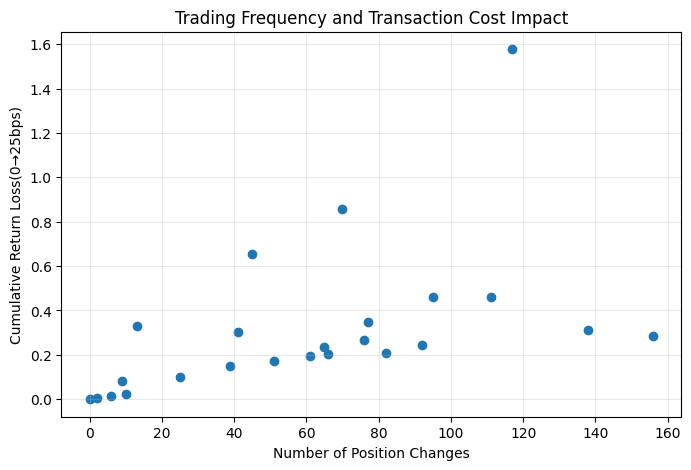

In [246]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(
    cost_impact["Position Changes"],
    cost_impact["Return Loss(0→25bps)"]
)
plt.xlabel("Number of Position Changes")
plt.ylabel("Cumulative Return Loss(0→25bps)")
plt.title("Trading Frequency and Transaction Cost Impact")
plt.grid(alpha=0.3)
plt.show()

In [247]:
def yearly_strategy_returns(stock):
    windows=[20,50,100,200]
   
    returns=stock["Return"]
    if isinstance(returns,pd.DataFrame):
        returns=returns.iloc[:,0]

    ma200=stock["MA200"]
    if isinstance(ma200,pd.DataFrame):
        ma200=ma200.iloc[:,0]

    first_valid_ma200=ma200.first_valid_index()
    start_pos=returns.index.get_loc(first_valid_ma200)+1
    start_date=returns.index[start_pos]
    
    data=pd.DataFrame({
        "Buy&Hold":returns
    })
    for window in windows:
        strategy=stock[f"Strategy{window}_Return"]

        if isinstance(strategy,pd.DataFrame):
            strategy=strategy.iloc[:,0]

        data[f"MA{window}"]=strategy
    data=data.dropna()
    results=[]
    for year,group in data.groupby(data.index.year):
        bh_return=(1+group["Buy&Hold"]).prod()-1
        for window in windows:
            strategy_return=(1+group[f"MA{window}"]
                            ).prod()-1
    
            results.append({
                 "Year":year,
                 "Strategy":f"MA{window}",
                 "Buy&Hold Return":bh_return,
                 "Strategy Return":strategy_return,
                 "Outperformance":strategy_return-bh_return
        })

    return pd.DataFrame(results)
            

In [248]:
yearly_results=[]

for stock_name,stock in stocks_dict.items():
    temp=yearly_strategy_returns(stock)
    temp["Stock"]=stock_name
    yearly_results.append(temp)

yearly_results=pd.concat(
    yearly_results,
    ignore_index=True
)


In [249]:
robustness_summary=(
    yearly_results
    .groupby("Strategy")
    .agg(
        Comparisons=("Outperformance","count"),
        Positive=("Outperformance",lambda x:(x>0).sum()),
        Mean_Outperformance=("Outperformance","mean"),
        Median_Outperformance=("Outperformance","median")
    )
)
robustness_summary["Win Rate"]=(
    robustness_summary["Positive"]
    /robustness_summary["Comparisons"]
)
robustness_summary=robustness_summary.reindex(
    ["MA20","MA50","MA100","MA200"]
)
robustness_summary.round(6)

,Comparisons,Positive,Mean_Outperformance,Median_Outperformance,Win Rate
Strategy,,,,,
MA20,26,4,-0.223056,-0.165442,0.153846
MA50,26,3,-0.217356,-0.172212,0.115385
MA100,26,5,-0.195300,-0.211971,0.192308
MA200,26,5,-0.168526,-0.049341,0.192308


In [250]:
down_years=yearly_results[
    yearly_results["Buy&Hold Return"]<0
].copy()
down_years["Loss Reduction"]=(
    down_years["Strategy Return"]
    -down_years["Buy&Hold Return"]
)
down_years.round(4)

,Year,Strategy,Buy&Hold Return,Strategy Return,Outperformance,Stock,Loss Reduction
8,2022,MA20,-0.2640,-0.0558,0.2082,AAPL,0.2082
9,2022,MA50,-0.2640,-0.2750,-0.0109,AAPL,-0.0109
10,2022,MA100,-0.2640,-0.2398,0.0242,AAPL,0.0242
11,2022,MA200,-0.2640,-0.2504,0.0136,AAPL,0.0136
28,2022,MA20,-0.2802,-0.3223,-0.0420,MSFT,-0.0420
29,2022,MA50,-0.2802,-0.1201,0.1602,MSFT,0.1602
30,2022,MA100,-0.2802,-0.1895,0.0908,MSFT,0.0908
31,2022,MA200,-0.2802,-0.2187,0.0615,MSFT,0.0615
48,2022,MA20,-0.5026,0.1164,0.6191,NVDA,0.6191
49,2022,MA50,-0.5026,-0.1223,0.3804,NVDA,0.3804


In [251]:
downside_summary=(
    down_years
    .groupby("Strategy")
    .agg(
        Down_Year_Comparisons=("Loss Reduction","count"),
        Loss_Reduced=("Loss Reduction",lambda x:(x>0).sum()),
        Mean_Loss_Reduction=("Loss Reduction","mean"),
        Median_Loss_Reduction=("Loss Reduction","median")
    )
)
downside_summary["protection Rate"]=(
    downside_summary["Loss_Reduced"]
    /downside_summary["Down_Year_Comparisons"]
)
downside_summary.round(4)

,Down_Year_Comparisons,Loss_Reduced,Mean_Loss_Reduction,Median_Loss_Reduction,protection Rate
Strategy,,,,,
MA100,6,4,-0.0111,0.0575,0.6667
MA20,6,2,0.0283,-0.0347,0.3333
MA200,6,4,-0.0202,0.0375,0.6667
MA50,6,2,-0.0092,-0.0641,0.3333


In [252]:
TRADING_DAYS=252
ANNUAL_RF=0.0497
daily_rf=(1+ANNUAL_RF)**(1/TRADING_DAYS)-1

def portfolio_metrics(returns):
    returns=returns.dropna()

    annual_return=returns.mean()*TRADING_DAYS
    annual_vol=returns.std()*np.sqrt(TRADING_DAYS)

    excess_returns=returns-daily_rf
    sharpe=(
        excess_returns.mean()
        /excess_returns.std()
        *np.sqrt(TRADING_DAYS)
    )
    wealth=(1+returns).cumprod()
    cumulative_return=wealth.iloc[-1]-1

    drawdown=wealth/wealth.cummax()-1
    max_drawdown=drawdown.min()
    rolling_vol=(
        returns.rolling(30).std()
        *np.sqrt(TRADING_DAYS)
    ).mean()
    return{
         "Annualized Arithmetic Return":annual_return,
         "Annualized Volatility":annual_vol,
         "Formal Sharpe Ratio":sharpe,
         "Maximum Drawdown":max_drawdown,
         "Cumulative Return":cumulative_return,
         "Mean 30-Day Rolling Volatility":rolling_vol
    }
final_portfolio_table=pd.DataFrame({
    "U.S. Technology":portfolio_metrics(us_portfolio_matched),
    "Kazakhstan-Related":portfolio_metrics(kz_portfolio_matched)
}).T
final_portfolio_table.round(6)


,Annualized Arithmetic Return,Annualized Volatility,Formal Sharpe Ratio,Maximum Drawdown,Cumulative Return,Mean 30-Day Rolling Volatility
U.S. Technology,0.468613,0.253185,1.659280,-0.169916,0.502140,0.255390
Kazakhstan-Related,0.199545,0.209886,0.719606,-0.123159,0.180108,0.207722


In [253]:
def diversification_metrics(asset_returns):
    asset_returns=asset_returns.dropna()

    if asset_returns.shape[1]<2:
        raise ValueError(
            "At least two assets are required to calculate correlations."
        )
    weights=np.repeat(
        1/asset_returns.shape[1],
        asset_returns.shape[1]
    )

    individual_vol=(
         asset_returns.std()
         *np.sqrt(TRADING_DAYS)
    )

    portfolio_returns=asset_returns.mean(axis=1)
    portfolio_vol=(
        portfolio_returns.std()*np.sqrt(TRADING_DAYS)
    )

    diversification_ratio=(
         np.dot(weights,individual_vol)
        /portfolio_vol
    )
    rolling_corr=asset_returns.rolling(30).corr()
    pairwise_corrs=[]
    columns=asset_returns.columns
    for i in range(len(columns)):
        for j in range(i+1,len(columns)):
            pair_corr=rolling_corr.loc[
                (slice(None),columns[i]),
                columns[j]
                ]
            pair_corr.index=pair_corr.index.droplevel(1)
            pairwise_corrs.append(pair_corr)

        avg_pairwise_rolling_corr=pd.concat(
            pairwise_corrs,
            axis=1
        ).mean(axis=1)

        mean_rolling_corr=avg_pairwise_rolling_corr.mean()
        

        return diversification_ratio, mean_rolling_corr

In [254]:
us_dr,us_rolling_corr=diversification_metrics(us_matched)
kz_dr,kz_rolling_corr=diversification_metrics(kz_matched)

final_portfolio_table["Diversification Ratio"]=[
    us_dr,
    kz_dr
]
final_portfolio_table["Mean 30-Day Rolling Correlation"]=[
    us_rolling_corr,
    kz_rolling_corr
]
final_portfolio_table.round(6)

,Annualized Arithmetic Return,Annualized Volatility,Formal Sharpe Ratio,Maximum Drawdown,Cumulative Return,Mean 30-Day Rolling Volatility,Diversification Ratio,Mean 30-Day Rolling Correlation
U.S. Technology,0.468613,0.253185,1.659280,-0.169916,0.502140,0.255390,1.266054,0.368574
Kazakhstan-Related,0.199545,0.209886,0.719606,-0.123159,0.180108,0.207722,1.540916,0.100079


In [255]:
downside_summary["Protection Rate"]=(
    downside_summary["Loss_Reduced"]
    /downside_summary["Down_Year_Comparisons"]
)

In [256]:
final_ma_robustness_table=(
    robustness_summary[
        [
            "Comparisons",
            "Positive",
            "Mean_Outperformance",
            "Median_Outperformance",
            "Win Rate"
        ]
    ]
    .join(
        downside_summary[
            [
                "Down_Year_Comparisons",
                "Loss_Reduced",
                "Mean_Loss_Reduction",
                "Median_Loss_Reduction",
                "Protection Rate"
            ]
        ]
    )
)
final_ma_robustness_table.round(6)

,Comparisons,Positive,Mean_Outperformance,Median_Outperformance,Win Rate,Down_Year_Comparisons,Loss_Reduced,Mean_Loss_Reduction,Median_Loss_Reduction,Protection Rate
Strategy,,,,,,,,,,
MA20,26,4,-0.223056,-0.165442,0.153846,6,2,0.028313,-0.034731,0.333333
MA50,26,3,-0.217356,-0.172212,0.115385,6,2,-0.009221,-0.064133,0.333333
MA100,26,5,-0.195300,-0.211971,0.192308,6,4,-0.011073,0.057491,0.666667
MA200,26,5,-0.168526,-0.049341,0.192308,6,4,-0.020205,0.037548,0.666667


In [257]:
final_transaction_cost_table=(
    transaction_cost_table
    .pivot_table(
        index=["Stock","Strategy"],
        columns="Cost (bps)",
        values="Cumulative Return"
    )
    .reset_index()
)
final_transaction_cost_table=(
    final_transaction_cost_table
    .rename(columns={
        0:"Return(0 bps)",
        10:"Return(10 bps)",
        25:"Return(25 bps)"
    })      
)
trade_counts=(
    transaction_cost_table[
        transaction_cost_table["Cost (bps)"]==0
    ][
        ["Stock","Strategy","Position Changes"]
    ]
)

final_transaction_cost_table=(
    final_transaction_cost_table
    .merge(
        trade_counts,
        on=["Stock","Strategy"],
        how="left"
    )
)
final_transaction_cost_table["Return Loss(0→25bps)"]=(
    final_transaction_cost_table["Return(0 bps)"]
    -final_transaction_cost_table["Return(25 bps)"]
)
final_transaction_cost_table.round(6)
         

,Stock,Strategy,Return(0 bps),Return(10 bps),Return(25 bps),Position Changes,Return Loss(0→25bps)
0,AAPL,MA100,0.428427,0.357353,0.257198,51.0,0.171229
1,AAPL,MA20,1.178824,0.981865,0.718995,95.0,0.459829
2,AAPL,MA200,0.679489,0.637976,0.577549,25.0,0.101940
3,AAPL,MA50,0.560101,0.461735,0.325529,65.0,0.234572
4,HSBK,MA100,2.090820,1.966087,1.788146,41.0,0.302674
5,HSBK,MA20,0.887857,0.688807,0.428581,111.0,0.459276
6,HSBK,MA200,2.609103,2.576539,2.528182,9.0,0.080921
7,HSBK,MA50,0.974245,0.827317,0.626933,77.0,0.347312
8,KAP,MA100,0.119710,0.031522,-0.088051,82.0,0.207762
9,KAP,MA20,-0.113225,-0.241387,-0.399927,156.0,0.286702


In [258]:
cost_turnover_correlation=(
    final_transaction_cost_table[
        ["Position Changes","Return Loss(0→25bps)"]
    ]
    .corr()
    .iloc[0,1]
)
print(
    f"Correlation between Position Changes and "
    f"Return Loss(0→25bps):"
    f"{cost_turnover_correlation:.6f}"
)

Correlation between Position Changes and Return Loss(0→25bps):0.491774


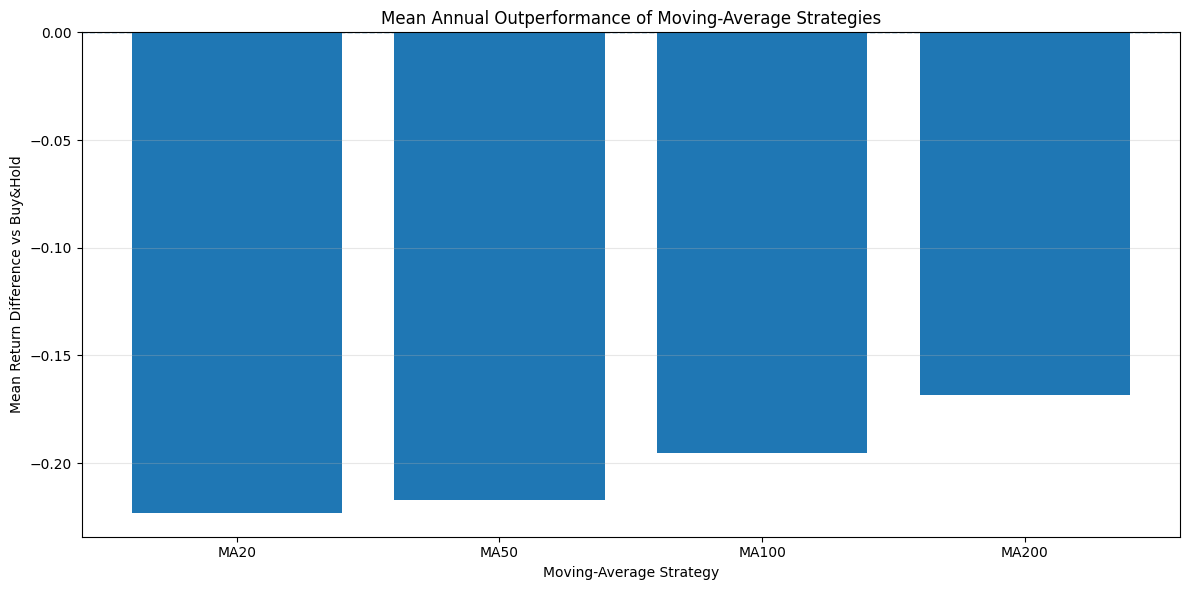

In [259]:
ma_outperformance=(
    yearly_results
    .groupby("Strategy")["Outperformance"]
    .mean()
    .reindex(["MA20","MA50","MA100","MA200"])
)
plt.figure(figsize=(12,6))
plt.bar(
    ma_outperformance.index,
    ma_outperformance.values
)
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)
plt.title(
    "Mean Annual Outperformance of Moving-Average Strategies"
)
plt.xlabel("Moving-Average Strategy")
plt.ylabel("Mean Return Difference vs Buy&Hold")

plt.grid(axis="y",alpha=0.3)
plt.tight_layout()
plt.show()

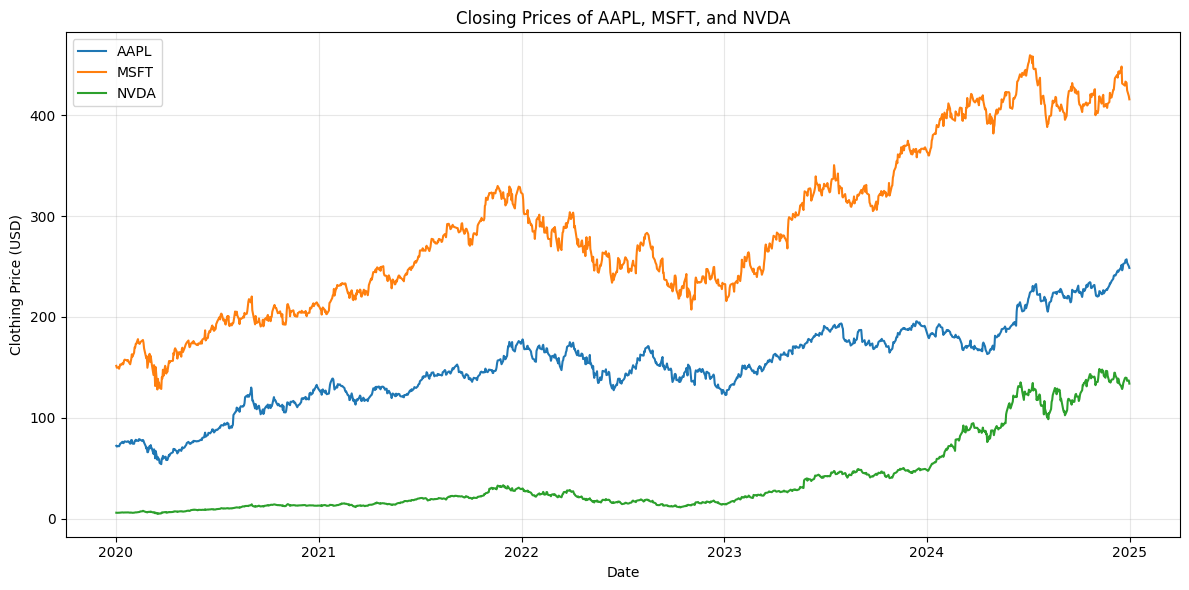

In [267]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(apple.index,apple["Close"],label="AAPL")
plt.plot(msft.index,msft["Close"],label="MSFT")
plt.plot(nvda.index,nvda["Close"],label="NVDA")

plt.title("Closing Prices of AAPL, MSFT, and NVDA")
plt.xlabel("Date")
plt.ylabel("Clothing Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

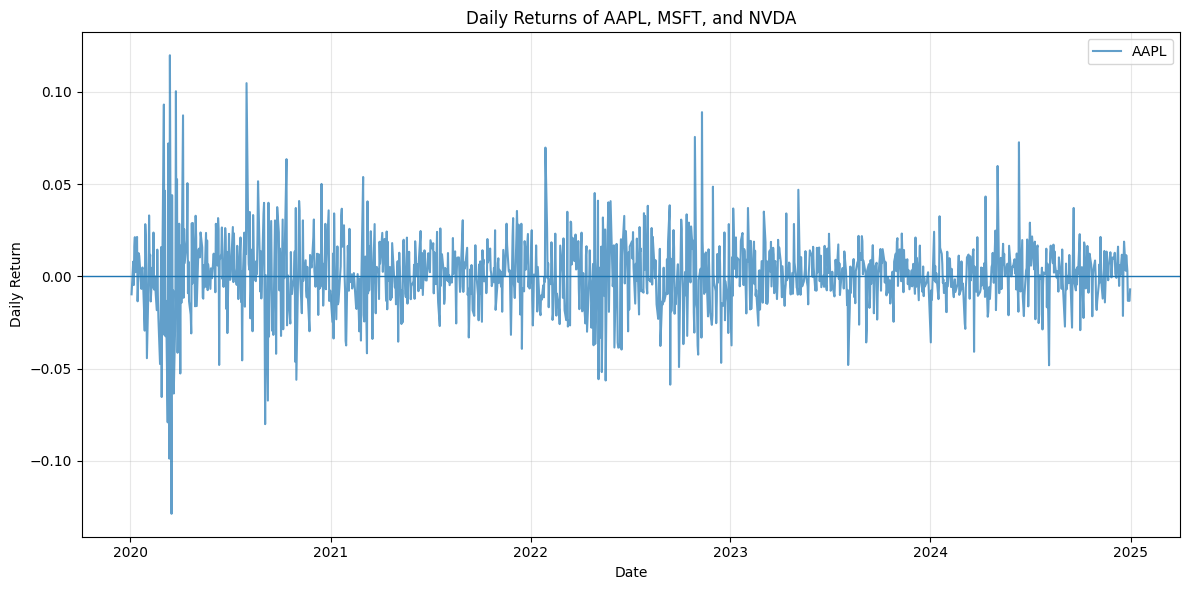

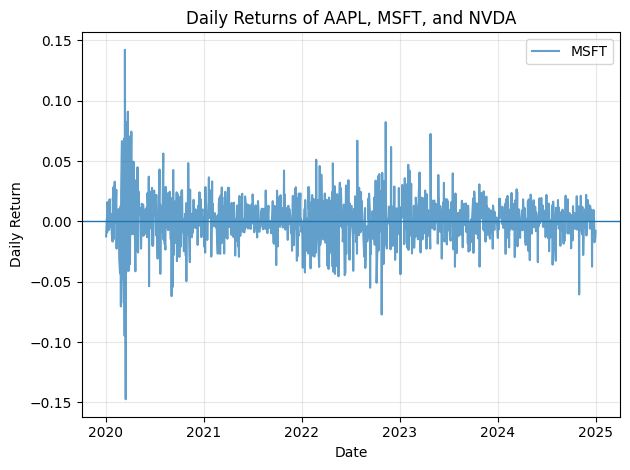

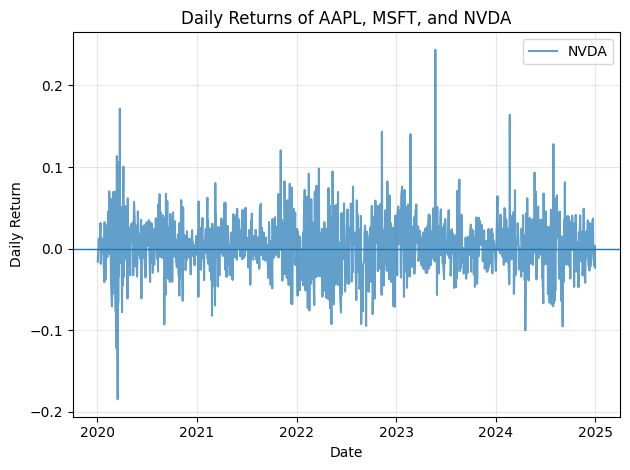

In [273]:
plt.figure(figsize=(12,6))
for stock, name in [
    (apple,"AAPL"),
    (msft,"MSFT"),
    (nvda,"NVDA")
]:
    returns=stock["Return"]

    if isinstance(returns,pd.DataFrame):
        returns=returns.iloc[:,0]
    plt.plot(
        returns.index,
        returns,
        label=name,
        alpha=0.7
    )
    plt.axhline(0,linewidth=1)
    plt.title("Daily Returns of AAPL, MSFT, and NVDA")
    plt.xlabel("Date")
    plt.ylabel("Daily Return")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

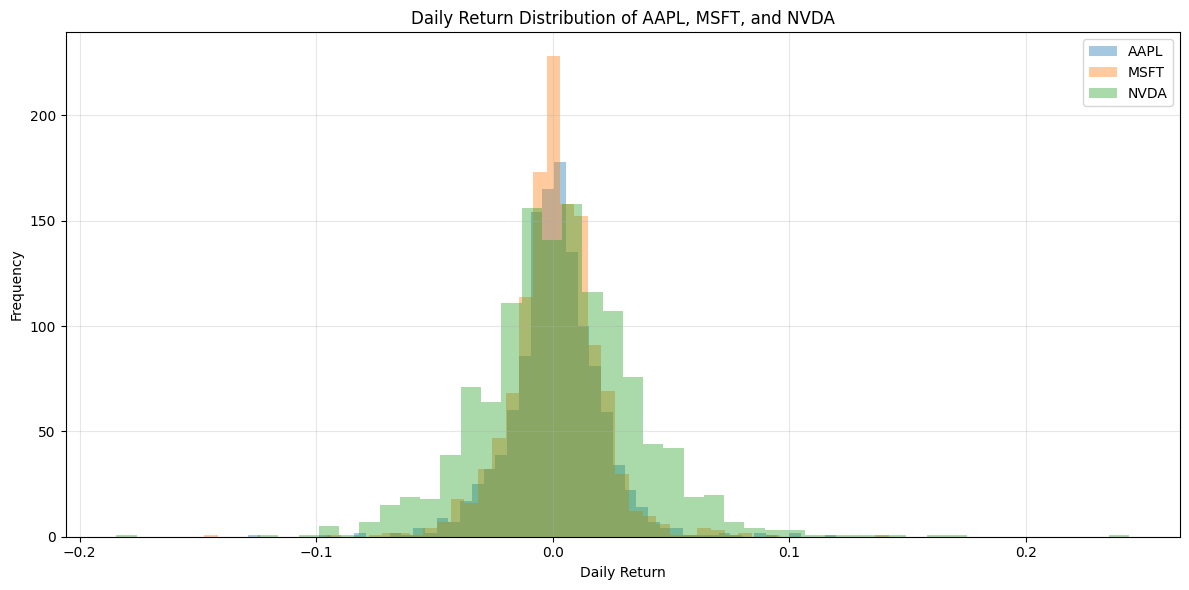

In [275]:
plt.figure(figsize=(12,6))
for stock, name in[
    (apple,"AAPL"),
    (msft,"MSFT"),
    (nvda,"NVDA")
]:
    returns=stock["Return"]

    if isinstance(returns,pd.DataFrame):
        returns=returns.iloc[:,0]

    plt.hist(
        returns.dropna(),
        bins=50,
        alpha=0.4,
        label=name
    )
plt.title("Daily Return Distribution of AAPL, MSFT, and NVDA")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

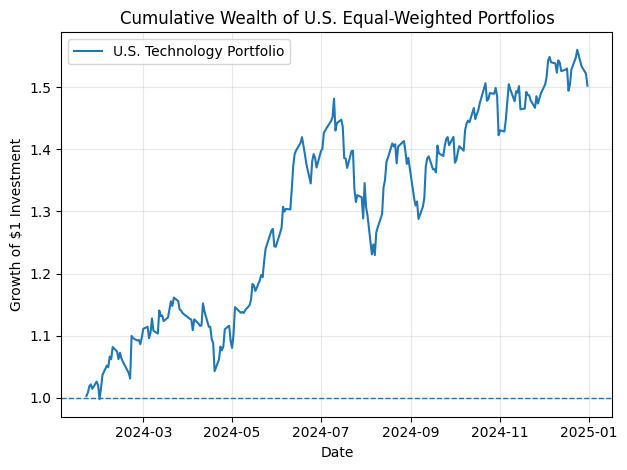

In [276]:
import matplotlib.pyplot as plt
plt.plot(
    us_wealth.index,
    us_wealth,
    label="U.S. Technology Portfolio"
)

plt.axhline(
    y=1,
    linestyle="--",
    linewidth=1
)

plt.title("Cumulative Wealth of U.S. Equal-Weighted Portfolios")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

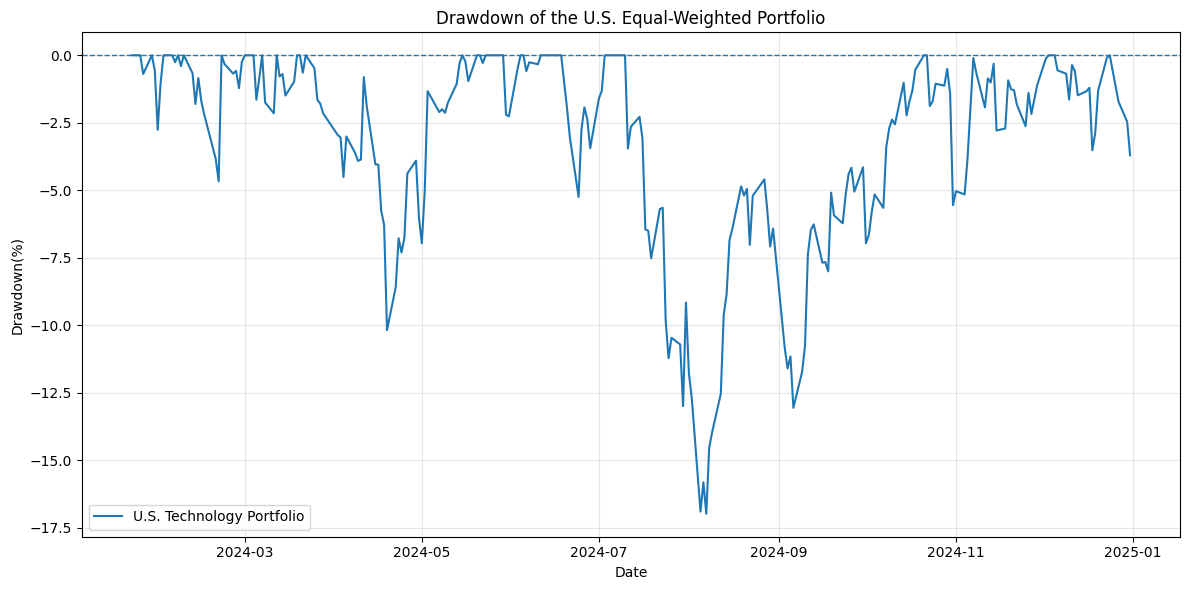

In [277]:
#Plot Drawdown Curves
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(
    us_drawdown.index,
    us_drawdown*100,
    label="U.S. Technology Portfolio"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("Drawdown of the U.S. Equal-Weighted Portfolio")
plt.xlabel("Date")
plt.ylabel("Drawdown(%)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

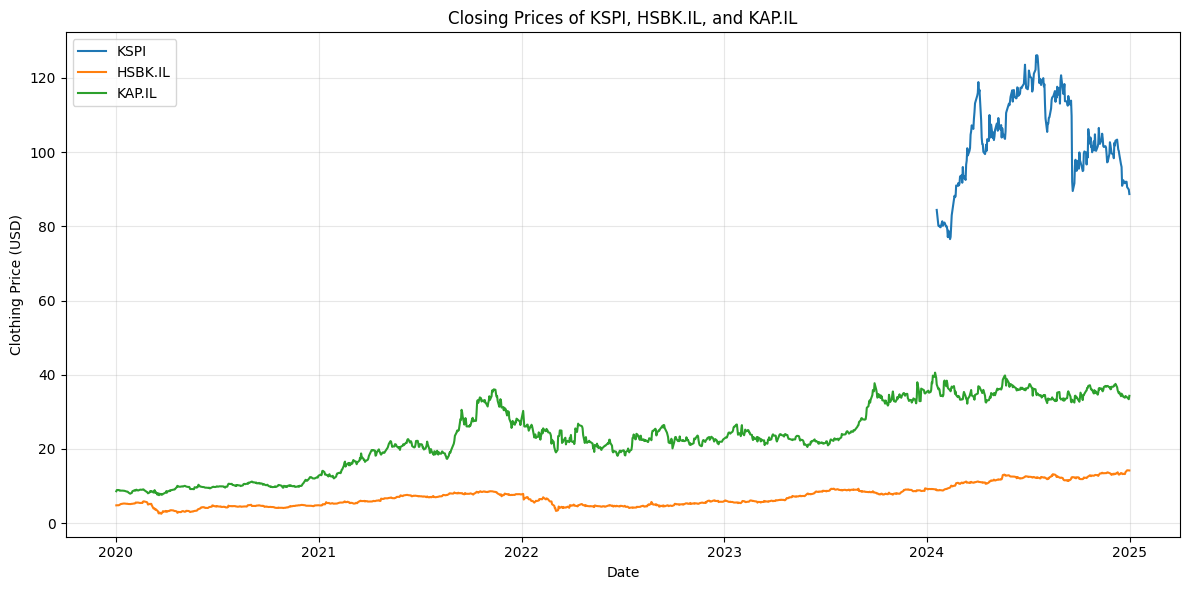

In [291]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(kaspi.index,kaspi["Close"],label="KSPI")
plt.plot(halyk.index,halyk["Close"],label="HSBK.IL")
plt.plot(kap.index,kap["Close"],label="KAP.IL")

plt.title("Closing Prices of KSPI, HSBK.IL, and KAP.IL")
plt.xlabel("Date")
plt.ylabel("Clothing Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

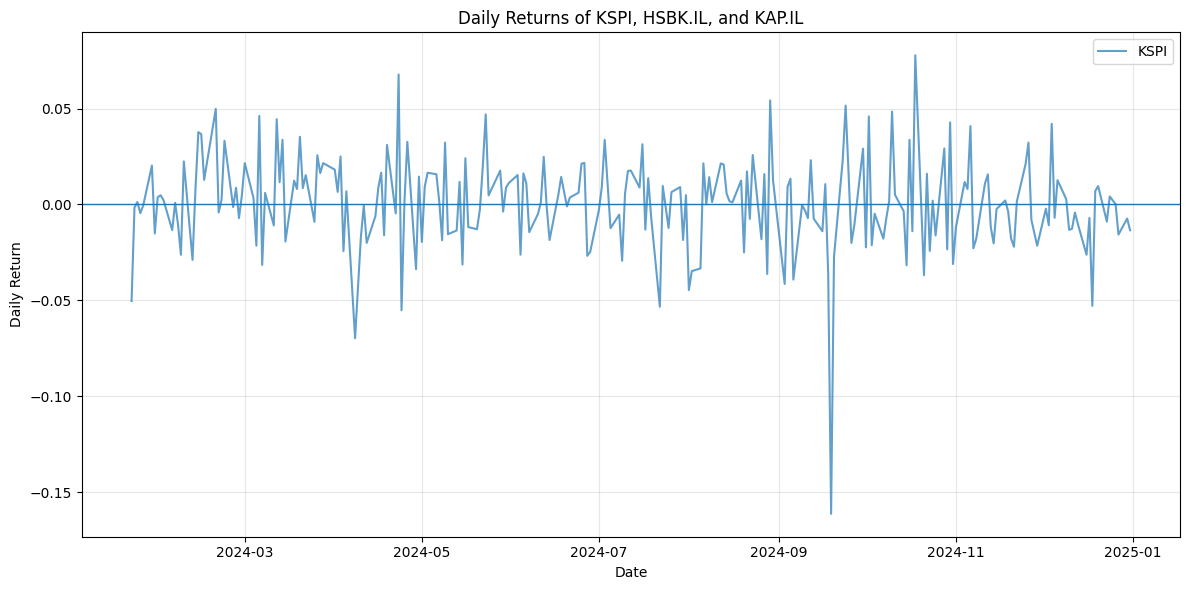

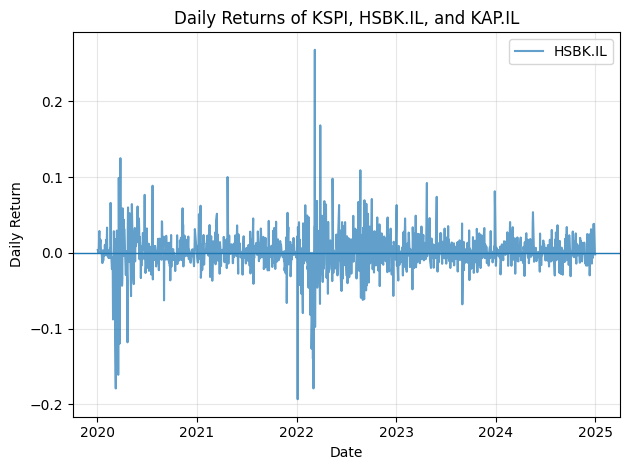

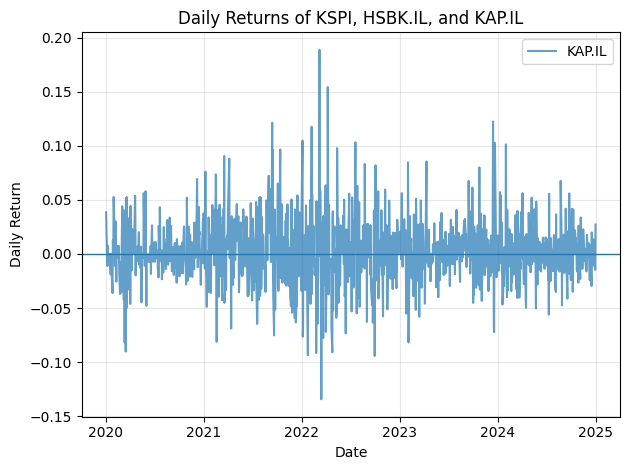

In [290]:
plt.figure(figsize=(12,6))
for stock, name in [
    (kaspi,"KSPI"),
    (halyk,"HSBK.IL"),
    (kap,"KAP.IL")
]:
    returns=stock["Return"]

    if isinstance(returns,pd.DataFrame):
        returns=returns.iloc[:,0]
    plt.plot(
        returns.index,
        returns,
        label=name,
        alpha=0.7
    )
    plt.axhline(0,linewidth=1)
    plt.title("Daily Returns of KSPI, HSBK.IL, and KAP.IL")
    plt.xlabel("Date")
    plt.ylabel("Daily Return")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

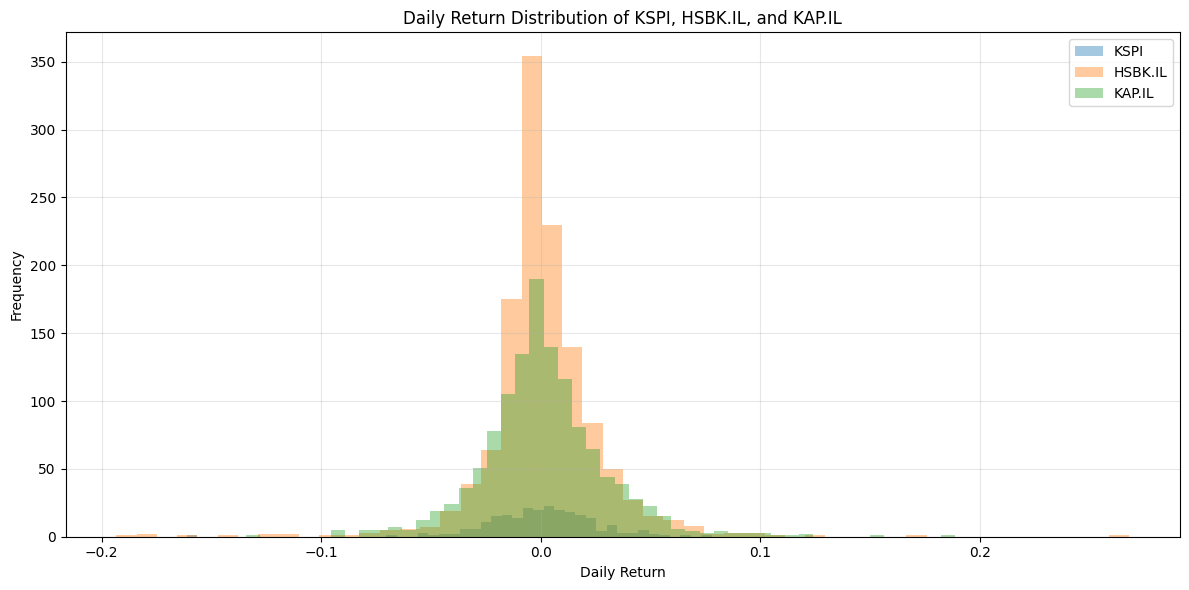

In [292]:
plt.figure(figsize=(12,6))
for stock, name in[
    (kaspi,"KSPI"),
    (halyk,"HSBK.IL"),
    (kap,"KAP.IL")
]:
    returns=stock["Return"]

    if isinstance(returns,pd.DataFrame):
        returns=returns.iloc[:,0]

    plt.hist(
        returns.dropna(),
        bins=50,
        alpha=0.4,
        label=name
    )
plt.title("Daily Return Distribution of KSPI, HSBK.IL, and KAP.IL")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

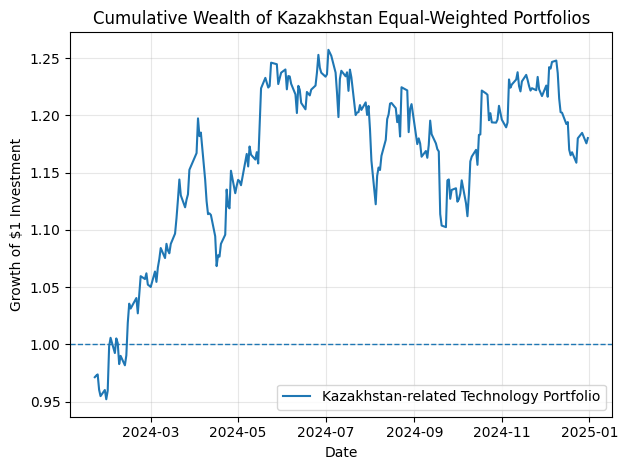

In [293]:
import matplotlib.pyplot as plt
plt.plot(
    kz_wealth.index,
    kz_wealth,
    label="Kazakhstan-related Technology Portfolio"
)

plt.axhline(
    y=1,
    linestyle="--",
    linewidth=1
)

plt.title("Cumulative Wealth of Kazakhstan Equal-Weighted Portfolios")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

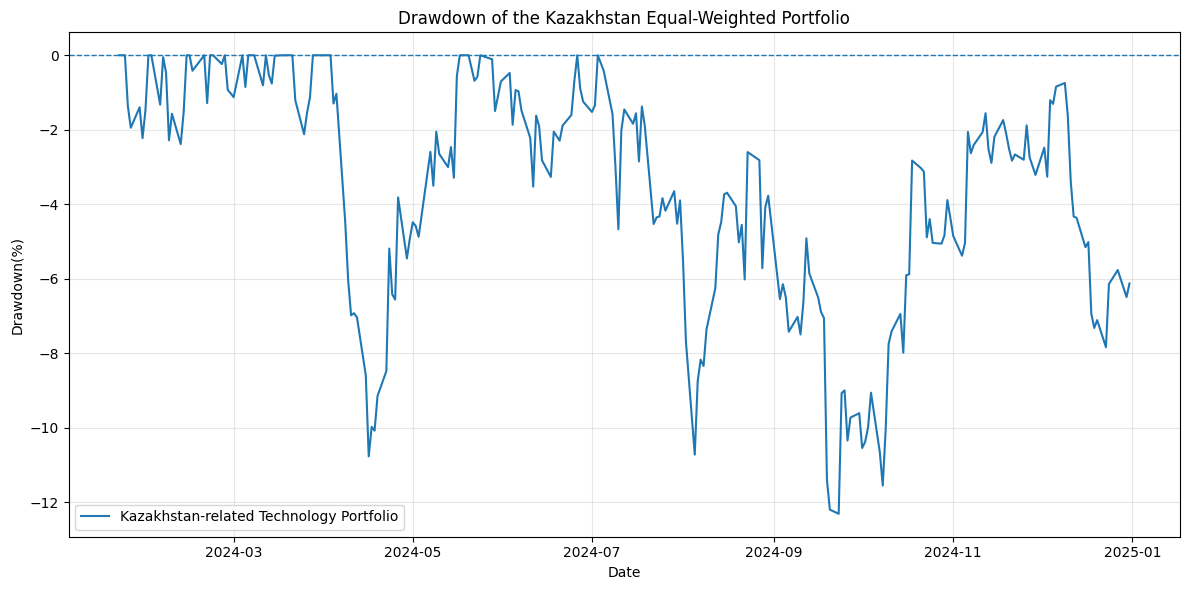

In [295]:
#Plot Drawdown Curves
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(
    kz_drawdown.index,
    kz_drawdown*100,
    label="Kazakhstan-related Technology Portfolio"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("Drawdown of the Kazakhstan Equal-Weighted Portfolio")
plt.xlabel("Date")
plt.ylabel("Drawdown(%)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()